# Process GM-SEUS for All Final Attributes
This includes: Installation Year, Ground Cover Ratio, Module Type, Agrivoltaic Type, Module Efficiency, and Installed Capacity 

NOTE: This script is currently set up to output each intermediate product for observation. The code chunks are meant to run in order, requiring the prior chunks output for the next's inputs. This means when we update code, we have to doublecheck that files are being called from the prior chunk for updated data. 

**Important notes for v1.0 of this script and dataset**
* **Regarding panel-rows that overlap multiple arrays**: The initial panel-row dataset (GMSEUS_Panels_ExistingAndNAIP.shp) contains 460 duplicate panelID's. Additionally, when we copy arrayID's via spatial join (twice, once in _Assign Final Panel-Row Attributes to Panel-Rows** and again in _For arrays with duplicated infomration, group and distribute attributes to arrays and panels accordingly_), panel-rows that overlap multiple arrays end up being duplicated. Currently, we maintain these for the purpose of attribution of variables to arrays, but then remove them in the final panel-row output so that panel-row dataset contains only unique panel rows (counting panel-row area only once). **If this information is desired, panel-rows can either be re-spatially joined with arrays (easiest path) thus creating duplicates, or use one of the intermediateProduct files.

# Import Libraries and Variables

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import os 
from shapely.ops import unary_union
from shapely.ops import nearest_points

# Import sns
import seaborn as sns

# Import matplotlib
import matplotlib.pyplot as plt

# Import gmseusUtils
import gmseusUtils as gu

In [2]:
# Set folder paths
wd = r'S:\Users\stidjaco\R_files\BigPanel'
downloaded_path = os.path.join(wd, r'Data\Downloaded')
derived_path = os.path.join(wd, r'Data\Derived')
derivedTemp_path = os.path.join(derived_path, r'intermediateProducts')
figure_path = os.path.join(wd, r'Figures')

# Set a GM-SEUS array path for acquiring installation year (exploded grouped arrays -- SAM) and panel path
gmseusArraysInstYrPath = os.path.join(derivedTemp_path, r'GMSEUS_Arrays_GroundMounted.shp')
gmseusPanelsCombinedPath = os.path.join(derivedTemp_path, r'GMSEUS_Panels_GroundMounted.shp')

# Set USPVDB path for checking installation year and panel data
uspvdb_path = os.path.join(derivedTemp_path, r'uspvdb_poly.shp')

# Get other source datasets for interpreting array area bias
cecsfc_path = os.path.join(derivedTemp_path, r'cecsfc_poly.shp')
osm_path = os.path.join(derivedTemp_path, r'osm_poly.shp')
ccvpv_path = os.path.join(derivedTemp_path, r'ccvpv_poly.shp')
tzsam_path = os.path.join(derivedTemp_path, r'tzsam_poly.shp')
grw_path = os.path.join(derivedTemp_path, r'grw_poly.shp')
cwsd_path = os.path.join(derivedTemp_path, r'cwsd_poly.shp')

# Set installation year file paths
instYr_folder = os.path.join(derivedTemp_path, r'getInstallationYearGEEOutput')

# Set gmseusArraysInstYr spatially joined with point data path and final instYr path
instYr_data_path = os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYrEst.csv')

# Set Tracking the Sun file path
tts_path = os.path.join(downloaded_path, r'TrackingTheSun\TTS_LBNL_public_file_29-Sep-2025_all.csv')

# Set county boundary file path
counties_path = os.path.join(downloaded_path, r'TIGER_Counties\tl_2019_us_county.shp')

# Load the config from the text file
config = gu.load_config('config.txt')

# Load variables
mostRecentInstallYear = config['mostRecentInstallYear'] # 2025, most recent installation year to consider for analysis
overlapDist = config['overlapDist'] # 190 meters, Set a overlap distance for checking if points/mismatched geometries between Solar PV datasets are duplicates
minPanelRowArea = config['minPanelRowArea'] # 15 m2, minimum area for a single panel row from the 1st percentile panel area from Stid et al., 2022
maxPanelRowArea = config['maxPanelRowArea'] # 254 m2 95th perccentile for a single panel row from Stid et al., 2022. MSU Solar Carport has max 1890m2
minNumPanelRows = config['minNumPanelRows'] # 3 panels, minimum number of panels rows to form a ground mounted solar array, definition from Stid et al., 2022
minPmArRatio = config['minPmArRatio'] # 18.8%, 20% was minimum ratio of panel perimeter to area ratio for panels from Stid et al., 2022, MSU Solar Carport has min 18.9%
panelArrayBuff = config['panelArrayBuff'] # 10m buffer, 20m maximum distance between panel rows to form an array. We used 5m in Stid et al., 2022, but there are lower packing factors at greater latitudes (nativeID: '1229957948')
arrayArrayBuff = config['arrayArrayBuff'] # 20m buffer, 40m maximum distance between arrays subsections of the same mount type to form a complete array. In Stid et al., 2022, we used 50m, but we checked for same installation year in addition to mount type.
lengthRatioThresh = config['lengthRatioThresh']  # If length ratio < 3.0, set to dual_axis or else fixed_axis_diagonal, else single- or fixed-axis
areaRatioThresh = config['areaRatioThresh']  # If area ratio < 0.15, set to fixed_diag_axis, else dual_axis
toCRS = config['to_crs']  # EPSG:6350 NAD83 (2011)

# Append toCRS with the EPSG prefix for use in GeoPandas
toCRS = f'EPSG:{toCRS}'

# Set aoi shapefile path
aoi_path = os.path.join(wd, r'Data\Downloaded\CONUS_NoGreatLakes\CONUS_No_Great_Lakes.shp')

# Get US Boundary to subset global/non-CONUS datasets
aoi = gpd.read_file(aoi_path) # CONUS boundary shapefile
aoi = aoi.set_crs(epsg=4269) # Native projection of US boundary - NAD83
aoi = aoi.to_crs(toCRS) # Transform to projection of USPVDB
aoi['geometry'] = aoi.buffer(10) # Buffer US boundary by 10 meters to ensure that array bounds are not clipped

# Set local and global arrayID columns (we rename these in this script as they become the final arrayID columns)
arrayIDcol = 'subArrID'
arrayIDcolGlob = 'tmpArrID'

# Estimate Installation Year and Build Final Array Dataset

### Load and Prepare Installation Year Outputs

In [130]:
# A function to load installation year data for each index and create a pandas dataframe
def loadInstYrData(index):
    # Get all csv files in the folder (lt_folder + index) and combine them into a single dataframe
    instYr_files = [os.path.join(instYr_folder, index, f) for f in os.listdir(os.path.join(instYr_folder, index)) if f.endswith('.csv')]
    instYr_data = pd.concat([pd.read_csv(f) for f in instYr_files])
    
    # Rename instYrLT column to instYrEst_index (BP originally indicated breakpoint)
    instYr_data = instYr_data.rename(columns={'instYrBP': 'instYrEst_' + index})
    return instYr_data

# Load data for each index
NDPVI = loadInstYrData('NDPVI')
NBD = loadInstYrData('NBD')
BR = loadInstYrData('BR')
NDWI = loadInstYrData('NDWI')
NDVI = loadInstYrData('NDVI')
EVI = loadInstYrData('EVI')
NBR = loadInstYrData('NBR')
NDMI = loadInstYrData('NDMI')
TCA = loadInstYrData('TCA')
TCG = loadInstYrData('TCG')
TCW = loadInstYrData('TCW')
TCB = loadInstYrData('TCB')

### Combine index datafarmes

In [131]:
# Create dataframe of arrayID, instYr, instYrLT_NDPVI, instYrLT_NBD. This process has been duplicating rows, prevent this from happpening
dataframes = [
    NDPVI,
    NBD[[arrayIDcol, 'instYrEst_NBD']],
    #BR[[arrayIDcol, 'instYrEst_BR']], # removed due to high MAE (>5 years)
    NDWI[[arrayIDcol, 'instYrEst_NDWI']],
    NDVI[[arrayIDcol, 'instYrEst_NDVI']],
    EVI[[arrayIDcol, 'instYrEst_EVI']],
    NBR[[arrayIDcol, 'instYrEst_NBR']],
    NDMI[[arrayIDcol, 'instYrEst_NDMI']], 
    TCA[[arrayIDcol, 'instYrEst_TCA']],
    TCG[[arrayIDcol, 'instYrEst_TCG']],
    #TCW[[arrayIDcol, 'instYrEst_TCW']], # removed due to high MAE (>5 years)
    #TCB[[arrayIDcol, 'instYrEst_TCB']] # removed due to high MAE (>5 years)
]

# Start with the first DataFrame
instYr_data = dataframes[0]

# Loop through the rest of the DataFrames and merge sequentially
for df in dataframes[1:]:
    instYr_data = pd.merge(instYr_data, df, on=arrayIDcol, how='left')

# Optionally, drop duplicate rows if necessary
instYr_data = instYr_data.drop_duplicates()

### Get Mean Absolute Error, Standard Deviation, and Index Weights for Each Index

In [132]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ MAE 

# For each index, set all <=2005 installation years to -9999 (default lower-bound value)
indices = ['NDPVI', 'NBD', 'NDWI', 'NDVI', 'EVI', 'NBR', 'NDMI', 'TCG', 'TCA'] # 'BR', 'TCW', 'TCB']
for index in indices:
    instYr_data.loc[instYr_data['instYrEst_' + index] <= 2005, 'instYrEst_' + index] = -9999

# Create a new dataframe with an index column and a MAE column
instYr_mae = pd.DataFrame(columns=['index', 'MAE'])

# Calculate the mean absolute error for each index
for index in indices:
    # Drop rows where instYr is -9999 or instYrLT_index is -9999
    instYr_data_temp  = instYr_data[(instYr_data['instYr'] != -9999) & (instYr_data['instYrEst_' + index] != -9999)]
    # Get arrays where Source = 'USPVDB'
    instYr_data_temp = instYr_data_temp[instYr_data_temp['Source'] == 'USPVDB']
    # Calculate the mean absolute error between instYr and instYrLT_index
    instYr_mae.loc[len(instYr_mae)] = [index, np.mean(np.abs(instYr_data_temp['instYr'] - instYr_data_temp['instYrEst_' + index]))]

# Print the mean absolute error for each index ordered by increasing MAE
#print(lt_mae.sort_values(by='MAE'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Standard Error and Inverse Variance Weight (1/std(metric error)^2)

# Initialize a dictionary to store standard deviation of errors for each index
std_errors = {}

# Calculate the standard deviation of errors for each index
for index in indices:
    # Drop rows where instYr is -9999 or instYrLT_index is -9999
    instYr_data_temp  = instYr_data[(instYr_data['instYr'] != -9999) & (instYr_data['instYrEst_' + index] != -9999)]
    # Get arrays where Source = 'USPVDB'
    instYr_data_temp = instYr_data_temp[instYr_data_temp['Source'] == 'USPVDB']
    # Calculate the error as the difference between actual and predicted years
    errors = instYr_data_temp["instYr"] - instYr_data_temp[f"instYrEst_{index}"]
    # Calculate standard deviation of errors
    std_errors[index] = errors.std()

# Convert the results to a DataFrame
instYr_std = pd.DataFrame.from_dict(std_errors, orient="index", columns=["std_metric_error"]).reset_index()
instYr_std.rename(columns={"index": "index"}, inplace=True)

# Calculate weights as 1/std(metric error)
instYr_std["weight"] = 1 / instYr_std["std_metric_error"]**2
# Print the DataFrame
#print(lt_std.sort_values(by='MAE'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Get weighted metric df

# Add MAE, STD, and weights by index
instYr_weights = instYr_mae.merge(instYr_std, on='index')

# Print the weighted metric DataFrame ordered by increasing MAE
print(instYr_weights.sort_values(by='MAE'))

   index       MAE  std_metric_error    weight
1    NBD  1.931031          3.588877  0.077640
6   NDMI  2.109294          3.761385  0.070681
4    EVI  2.219662          3.978268  0.063185
7    TCG  2.249806          3.965629  0.063588
0  NDPVI  2.324787          4.193285  0.056871
2   NDWI  2.389273          4.209944  0.056422
8    TCA  2.846400          4.577086  0.047733
3   NDVI  3.243188          4.993499  0.040104
5    NBR  3.288122          4.940347  0.040972


### Get Year of Detection with Most Index Votes

In [133]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Weighted Standard Deviation of the Error Method

# Define a function to calculate the most voted year based on the weighted sum of years
def most_voted_year(row, instYr_weights):
    
    # Initialize variables to store the weighted sum and weight sum
    weighted_sum = 0
    weight_sum = 0

    # Iterate over the columns in the row    
    for index, year in row.items():
        if year == -9999:  # Ignore invalid years
            continue
        index_name = index.replace("instYrEst_", "")  # Extract the index name
        # Get the weight for the index from std_df
        weight = instYr_weights.loc[instYr_weights['index'] == index_name, 'weight'].values
        if weight.size == 0:  # Handle cases where index is not found
            continue
        weight = weight[0]
        weighted_sum += year * weight
        weight_sum += weight
    
    # If no valid years were found, return -9999
    if weight_sum == 0:
        return -9999
    
    # Return the weighted average of years
    return round(weighted_sum / weight_sum)

# Dynamically select all columns starting with 'instYrEst_'
columns = [col for col in instYr_data.columns if col.startswith('instYrEst_')]

# Select instYrEst_index columns that have a MAE less than 2.5
MAEthreshold = 2.5
columnsMAE = instYr_weights[instYr_weights['MAE'] < MAEthreshold]['index'].apply(lambda x: 'instYrEst_' + x)

# Apply the new weighted voting function for low MAE columns then all columns to fill in -9999 gaps
instYr_data['instYrEst'] = instYr_data[columnsMAE].apply(lambda row: most_voted_year(row, instYr_weights), axis=1)
instYr_data['instYrEst'] = instYr_data['instYrEst'].where(instYr_data['instYrEst'] != -9999, instYr_data[columns].apply(lambda row: most_voted_year(row, instYr_weights), axis=1))  # Replace where value is -9999

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Fill null installation years for subarray shapes with metadata elewhere within the same array

# Load GM-SEUS Arrays
gmseusArrays = gpd.read_file(gmseusArraysInstYrPath)

# Attach area column from gmseusArrays by arrayIDcol
instYr_data = instYr_data.merge(gmseusArrays[[arrayIDcol, 'area']], on=arrayIDcol, how='left')

# For each arrayIDcol with the same arrayIDcolGlob, fill null values (-9999) with the installation year of the largest sub-array (by area)
for array_id in instYr_data[arrayIDcolGlob].unique():
    # Get the subset of the dataframe for the current arrayIDcolGlob
    subset = instYr_data[instYr_data[arrayIDcolGlob] == array_id]
    
    # Find the installation year of the largest sub-array (by area) that has a valid installation year
    largestSubArray = subset[subset['instYrEst'] != -9999].sort_values(by='area', ascending=False).head(1)
    
    if not largestSubArray.empty:
        fill_year = largestSubArray['instYrEst'].values[0]
        
        # Fill null values (-9999) in the subset with the fill_year
        instYr_data.loc[(instYr_data[arrayIDcolGlob] == array_id) & (instYr_data['instYrEst'] == -9999), 'instYrEst'] = fill_year

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Get results

# Fill NaN values in instYrLT with -9999
instYr_data['instYrEst'] = instYr_data['instYrEst'].fillna(-9999)

# Where Source is TZSAM, set instYr to -9999
instYr_data.loc[instYr_data['Source'] == 'TZSAM', 'instYr'] = -9999

# Print the total number of arrays with a newly detected installation year
print('Number of arrays with a newly detected installation year:', instYr_data['instYrEst'].value_counts().sum() - instYr_data['instYrEst'].value_counts()[-9999])
# Print the total number of arrays without a newly detected installation year
print('Number of arrays without a newly detected installation year from polygon sources:', instYr_data['instYrEst'].value_counts()[-9999])
# Print the total number of arrays without a newly detected installation year or an original installation year (for each row instYrLT = -9999 & instYr = -9999)
print('Number of arrays without a newly detected installation year or an original installation year:', instYr_data[(instYr_data['instYrEst'] == -9999) & (instYr_data['instYr'] == -9999)].shape[0])

# Export the final dataset
instYr_data.to_csv(instYr_data_path, index=False)

Number of arrays with a newly detected installation year: 27639
Number of arrays without a newly detected installation year from polygon sources: 189
Number of arrays without a newly detected installation year or an original installation year: 124


### Plot Installation Year Deviation for a Single Index

Number of arrays with a newly detected installation year: 4014
Mean Absolute Error: 1.6948181365221724


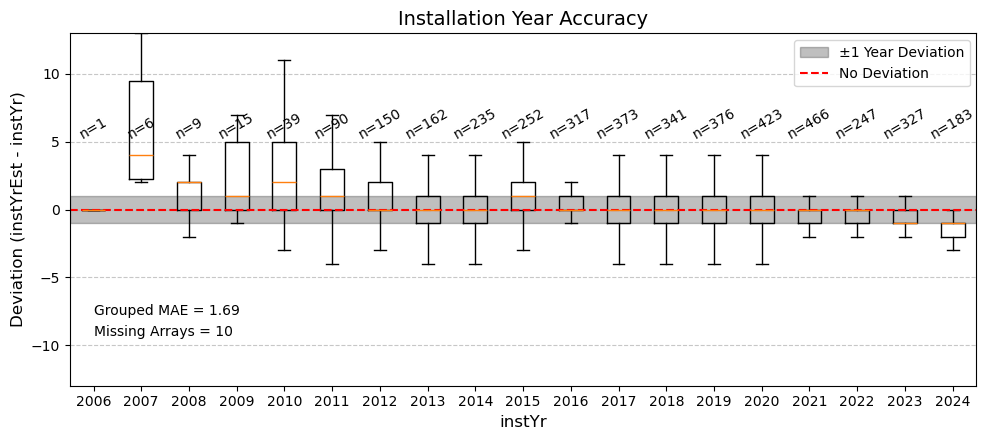

In [5]:
# Call lt_data
instYr_data = pd.read_csv(instYr_data_path)

# Group by tmpArrID, take most recent installation year where there are duplicates
instYr_data = instYr_data.sort_values(by='instYrEst', ascending=False).drop_duplicates(subset=[arrayIDcolGlob])

# Calculate the deviation
instYr_data['deviation'] = instYr_data['instYrEst'] - instYr_data['instYr']

# Remove any rows where instYrEst is -9999 or instYr is -9999
instYr_data_noNull = instYr_data[(instYr_data['instYrEst'] != -9999) & (instYr_data['instYr'] != -9999)]

# Drop rows where Source is anything other than USPVDB
instYr_data_noNull = instYr_data_noNull[instYr_data_noNull['Source'] == 'USPVDB']

# Print the total number of arrays with a newly detected installation year
print('Number of arrays with a newly detected installation year:', instYr_data_noNull['deviation'].value_counts().sum())

# Print the mean absolute deviation
print('Mean Absolute Error:', instYr_data_noNull['deviation'].abs().mean())

# Create a list of deviation values grouped by instYr and count the number of data points in each group
maxPlotYear = 2025
minPlotYear = 2006
data = [instYr_data_noNull[instYr_data_noNull['instYr'] == year]['deviation'] for year in range(minPlotYear, maxPlotYear)]
counts = [len(group) for group in data]

# Plot the boxplot without showing outliers
plt.figure(figsize=(10, 4.5))
# Add a shaded black (alpha = 0.25) that is plus or minus 1 year from the 0 line
plt.axhspan(-1, 1, color='black', alpha=0.25, label='±1 Year Deviation')

# Create the boxplot
plt.boxplot(data, positions=range(minPlotYear, maxPlotYear), widths=0.5, showfliers=False)

# Add the count (N) above each box, with a 30 degree rotation
for i, count in enumerate(counts):
    plt.text(minPlotYear + i, 5, f'n={count}', ha='center', va='bottom', fontsize=10, rotation=30)

# In the lower left corner, add the MAE and the difference between instYr_data nrows with instYr and instYrEst values not equal to -9999 and source USPVDB, and the nrows of instYr_data_noNull
plt.text(minPlotYear, -7, f'Grouped MAE = {instYr_data_noNull["deviation"].abs().mean():.2f}', ha='left', va='top', fontsize=10)
plt.text(minPlotYear, -8.5, f'Missing Arrays = {instYr_data[(instYr_data['instYr'] != -9999) & (instYr_data["Source"] == "USPVDB")].shape[0] - instYr_data_noNull.shape[0]}', ha='left', va='top', fontsize=10)

# Set x and y limits
plt.xlim(minPlotYear - 0.5, maxPlotYear - 0.5)
plt.ylim(-13, 13)

# Add labels, title, and grid
plt.xlabel('instYr', fontsize=12)
plt.ylabel('Deviation (instYrEst - instYr)', fontsize=12)
plt.title('Installation Year Accuracy', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a 0 line (no deviation)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='No Deviation')

# Add a legend
plt.legend()

# Show the plot
plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(figure_path, 'InstallationYear_Accuracy_BoxplotUSPVDB.png'), dpi=300)
plt.show()

### Plot Installation Year Deviation for All Indices

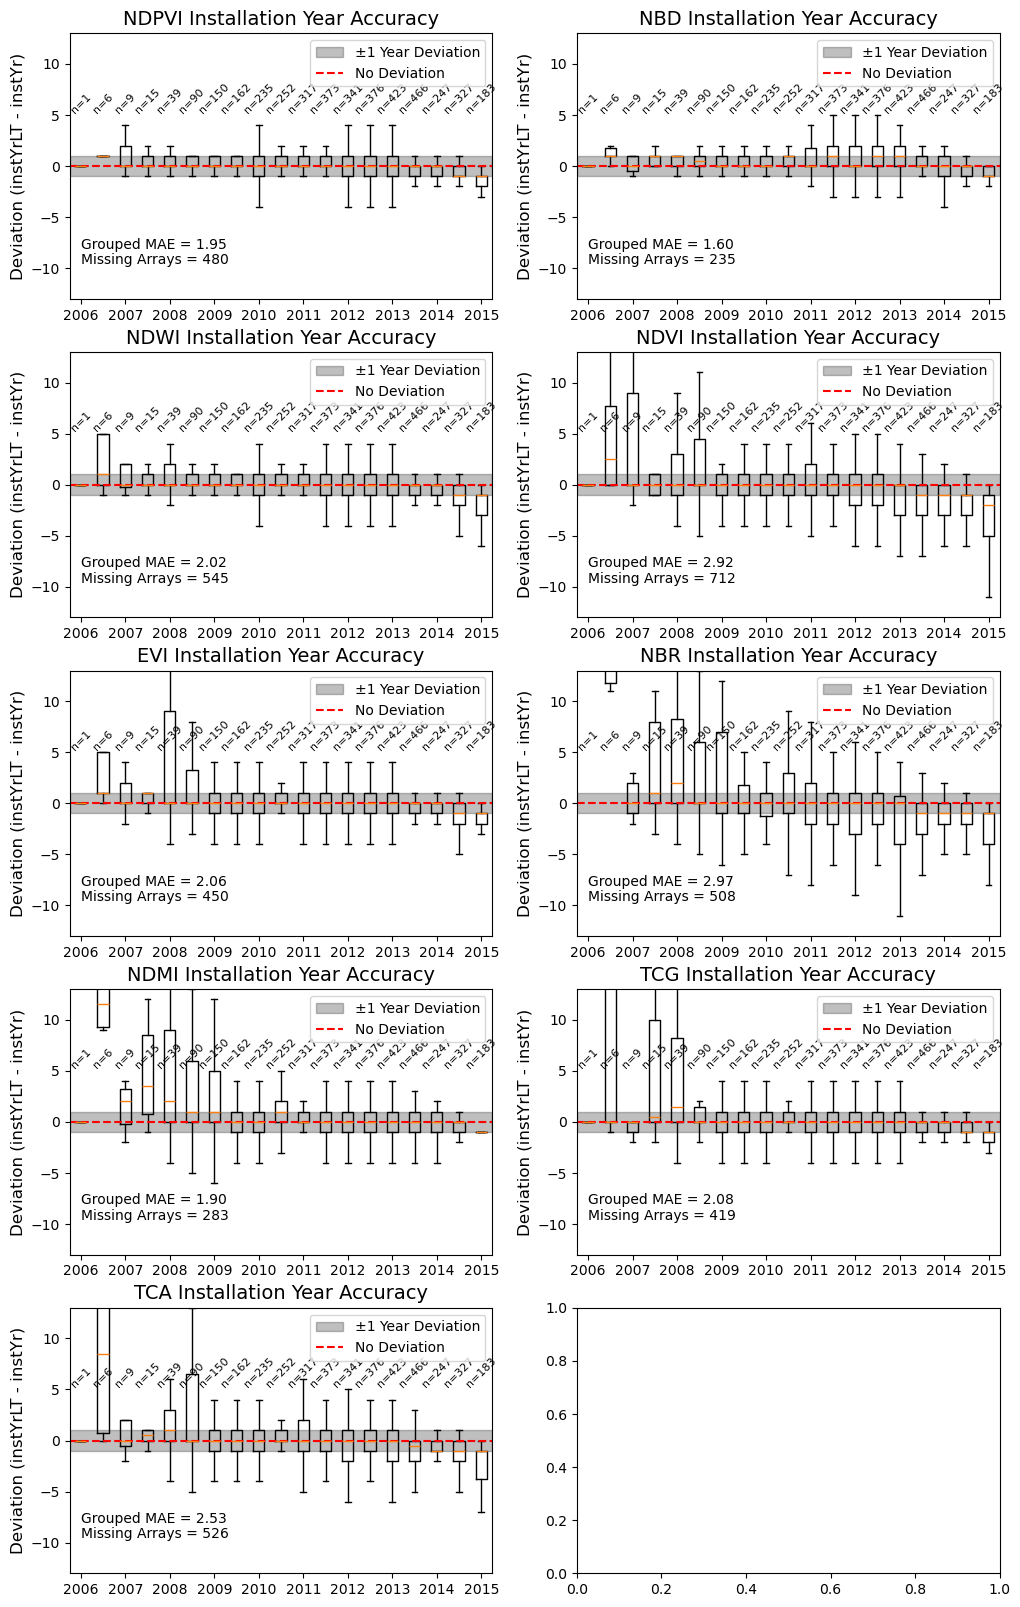

In [135]:
# Create the above graph, but for each index in a 4 row by 2 column grid
fig, axs = plt.subplots(5, 2, figsize=(12, 20))

# Iterate over each index
for i, index in enumerate(indices):
    # Calculate the deviation for the index
    instYr_data['deviation'] = instYr_data[f'instYrEst_{index}'] - instYr_data['instYr']

    # Remove any rows where instYrEst is -9999 or instYr is -9999
    instYr_data_noNull = instYr_data[(instYr_data[f'instYrEst_{index}'] != -9999) & (instYr_data['instYr'] != -9999)]

    # Drop rows where Source is anything other than USPVDB
    instYr_data_noNull = instYr_data_noNull[instYr_data_noNull['Source'] == 'USPVDB']

    # Create a list of deviation values grouped by instYr and count the number of data points in each group
    data = [instYr_data_noNull[instYr_data_noNull['instYr'] == year][f'deviation'] for year in range(minPlotYear, maxPlotYear)]

    # Plot the boxplot without showing outliers
    axs[i // 2, i % 2].axhspan(-1, 1, color='black', alpha=0.25, label='±1 Year Deviation')
    axs[i // 2, i % 2].boxplot(data, positions=range(minPlotYear, maxPlotYear), widths=0.5, showfliers=False)

    # Add the count (N) above each box, angle this text to be more readable by rotating it 45 degrees and make
    for j, count in enumerate(counts):
        axs[i // 2, i % 2].text(minPlotYear + j, 5, f'n={count}', ha='center', va='bottom', fontsize=8, rotation=45)

    # In the lower left corner, add the MAE and the difference between lt_data nrows with instYr and instYrLT values not equal to -9999 and source USPVDB, and the nrows of lt_data_noNull
    axs[i // 2, i % 2].text(minPlotYear, -7, f'Grouped MAE = {instYr_data_noNull[f"deviation"].abs().mean():.2f}', ha='left', va='top', fontsize=10)
    axs[i // 2, i % 2].text(minPlotYear, -8.5, f'Missing Arrays = {instYr_data[(instYr_data["instYr"] != -9999) & (instYr_data["Source"] == "USPVDB")].shape[0] - instYr_data_noNull.shape[0]}', ha='left', va='top', fontsize=10)

    # Set x and y limits, and ensure only every other year is shown on the x-axis
    axs[i // 2, i % 2].set_xlim(minPlotYear - 0.5, maxPlotYear - 0.5)
    axs[i // 2, i % 2].set_ylim(-13, 13)
    axs[i // 2, i % 2].set_xticks(range(minPlotYear, maxPlotYear, 2))

    # Add labels, title, and grid
    axs[i // 2, i % 2].set_xlabel('', fontsize=12)
    axs[i // 2, i % 2].set_ylabel('Deviation (instYrLT - instYr)', fontsize=12)
    axs[i // 2, i % 2].set_title(f'{index} Installation Year Accuracy', fontsize=14)

    # Add a 0 line (no deviation)
    axs[i // 2, i % 2].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='No Deviation')

    # Add a legend
    axs[i // 2, i % 2].legend()

# Export the plot
plt.savefig(os.path.join(figure_path, r'Installation_Year_Accuracy.png'))

### Assign Installation Year and Fill Gaps in instYr

In [10]:
# Call gmseusArraysInstYr that has been spatially joined with point data
gmseusArraysInstYr = gpd.read_file(gmseusArraysInstYrPath)

# Call installation year data
instYr_data = pd.read_csv(instYr_data_path)

# Merge the two datasets by arrayID
gmseusArraysInstYr = gmseusArraysInstYr.merge(instYr_data[[arrayIDcol, 'instYrEst']], on=arrayIDcol, how='left')

# Fill NaN values in instYr with -9999
gmseusArraysInstYr['instYr'] = gmseusArraysInstYr['instYr'].fillna(-9999)

# As a check, drop instYr for source CCVPV and TZSAM
gmseusArraysInstYr['instYr'] = gmseusArraysInstYr['instYr'].where(gmseusArraysInstYr['Source'] != 'CCVPV', -9999)
gmseusArraysInstYr['instYr'] = gmseusArraysInstYr['instYr'].where(gmseusArraysInstYr['Source'] != 'TZSAM', -9999)

# Get a temporary df where instYr and instYrEst are not -9999, and print the mean absolute error for all arrays, and those with Source = 'USPVDB'
print('Preliminary array stats after installation year assignment:')
gmseusArraysInstYr_noNull = gmseusArraysInstYr[(gmseusArraysInstYr['instYrEst'] != -9999) & (gmseusArraysInstYr['instYr'] != -9999)]
print('TEMP Mean Absolute Error ALL chunks:', np.mean(np.abs(gmseusArraysInstYr_noNull['instYr'] - gmseusArraysInstYr_noNull['instYrEst'])))
gmseusArraysInstYr_noNull = gmseusArraysInstYr_noNull[gmseusArraysInstYr_noNull['Source'] == 'USPVDB']
print('TEMP Mean Absolute Error USPVDB:', np.mean(np.abs(gmseusArraysInstYr_noNull['instYr'] - gmseusArraysInstYr_noNull['instYrEst'])))

# Where gmseusArraysInstYr['instYr'] is -9999, replace with instYrLT
gmseusArraysInstYr['instYr'] = gmseusArraysInstYr['instYr'].where(gmseusArraysInstYr['instYr'] != -9999, gmseusArraysInstYr['instYrEst'])

# Print the total number of arrays with an installation year
print('Number of arrays with an installation year:', gmseusArraysInstYr[gmseusArraysInstYr['instYr'] != -9999].shape[0])

# Print the total number of arrays without an installation year
print('Number of arrays without an installation year:', gmseusArraysInstYr[gmseusArraysInstYr['instYr'] == -9999].shape[0])

# Export the final instYr dataset (custom path)
gmseusArraysInstYr.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYr_joined.shp'))

Preliminary array stats after installation year assignment:
TEMP Mean Absolute Error ALL chunks: 2.4747556066705
TEMP Mean Absolute Error USPVDB: 1.9640266021765418
Number of arrays with an installation year: 27704
Number of arrays without an installation year: 124


## Compile a semi-final GM-SEUS Array Dataset Grouped By Installation Year
In `script4`, we exploded array shapes that originally were gropued into possibly erroneous arrays (because of low imagery resolution).\
Here, we will group these back into array shapes only if they share a common installation year (or are small array subsections that recieved a different installation year).\
After assigning final panel-row and array attributes, we will further group by mount and proximity (below).\

Note: We now manually digitize installation years after performing this operation

In [ ]:
# Call gmseusArraysInstYr
gmseusArraysInstYr = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYr_joined.shp'))

# Print original number of rows
print('Original number of rows:', gmseusArraysInstYr.shape[0])
# Print unique global arrayIDs
print('Original Number of unique global arrayIDs:', gmseusArraysInstYr[arrayIDcolGlob].nunique())

# (CHECK Script 4) Define non-confident array Sources where we replaced the original boundary
# NOTE: CCVPV and GMSEUSdigArraysPanels_v2_0 have been added because these boundaries are also derived by panel-rows, not user knowledge.
newBoundSources = ['TZSAM', 'OSM', 'GRW', 'CWSD', 'CECSFC', 'CCVPV', 'GMSEUSdigArraysPanels_v2_0']

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ For arrays with the same arrayID, group same instYr arrays and merge small arrays with nearest arrays
print(' -- Printing ArrayID grouping and merging stats -- ')

# Get gmseusArraysInstYr that have unique global arrayIDs and that have duplicate arrayIDs
gmseusArraysInstYrUnique = gmseusArraysInstYr[~gmseusArraysInstYr[arrayIDcolGlob].duplicated(keep=False)]
gmseusArraysInstYrDuplicate = gmseusArraysInstYr[gmseusArraysInstYr[arrayIDcolGlob].duplicated(keep=False)]

# Create a new list to store processed duplicates
processed_duplicates = []

# WITHIN ARRAY ID: Process only duplicate arrays 
for arrayID in gmseusArraysInstYrDuplicate[arrayIDcolGlob].unique():
    # Filter the rows for the current arrayID
    arrays = gmseusArraysInstYrDuplicate[gmseusArraysInstYrDuplicate[arrayIDcolGlob] == arrayID].copy()

    # Check if a sub-array chunk is missing an installation year (-9999), if so, fill with the most common installation year for that arrayID. If there are multiple modes, take largest one (as in most recent year)
    mask_year = arrays["instYr"].eq(-9999)
    if mask_year.any():
        # choose mode among KNOWN years only
        known = arrays.loc[~mask_year, "instYr"]
        if not known.empty:
            modes = known.mode()
            fill_year = int(modes.max())  # if tie, choose most recent
            arrays.loc[mask_year, "instYr"] = fill_year

    # Group by common instYr and set all other columns to their first value (copied attributes, so this is fine)
    arrays = arrays.dissolve(by='instYr', aggfunc='first').reset_index()

    # Set a tempID to track individual rows
    arrays['tempID'] = np.arange(1, len(arrays) + 1)

    # Iterate through each array row
    for array in arrays.itertuples():
        # Get the area of the array
        area = array.geometry.area

        # If the area is below the minimum threshold
        if area < minPanelRowArea * minNumPanelRows:
            # Get other arrays to consider for merging
            other_arrays = arrays[arrays['tempID'] != array.tempID]

            if not other_arrays.empty:
                # Find the nearest array geometry
                nearest_geom = nearest_points(array.geometry, unary_union(other_arrays.geometry))[1]
                nearest_array = other_arrays[other_arrays.geometry == nearest_geom]

                if not nearest_array.empty:
                    # Merge the small array with the nearest array
                    merged_geometry = nearest_geom.union(array.geometry)

                    # Update the geometry of the nearest array
                    arrays.loc[arrays['geometry'] == nearest_geom, 'geometry'] = merged_geometry

                    # Drop the small array
                    arrays = arrays[arrays['tempID'] != array.tempID]
        
        # If the area is less than 10% of the area of all subarray chunks with the same arrayID, drop the row
        if area < 0.1 * arrays['geometry'].area.sum():
            arrays = arrays[arrays['tempID'] != array.tempID]

    # Append processed arrays to the results
    processed_duplicates.append(arrays)

# Combine processed duplicates into a single GeoDataFrame
processed_duplicates = gpd.GeoDataFrame(pd.concat(processed_duplicates, ignore_index=True))

# Combine processed duplicates with unique arrays into the final result
gmseusArraysFinal = gpd.GeoDataFrame(pd.concat([gmseusArraysInstYrUnique, processed_duplicates], ignore_index=True))

# Drop arrayIDcol (not global, since some subarray chunks may still be separated), and reset a new  arrayID column that is 1 through the length of the dataset
gmseusArraysFinal = gmseusArraysFinal.reset_index(drop=True)
gmseusArraysFinal = gmseusArraysFinal.drop(columns=[arrayIDcol], errors='ignore')
gmseusArraysFinal[arrayIDcol] = np.arange(1, len(gmseusArraysFinal) + 1)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ For arrays with sources with non-confident spatial boundaries, merge by proximity, mount type, and installation year
print(' -- Printing non-confident boundary sources grouping and merging stats -- ')

# Fill mount None values with 'Unknown'
gmseusArraysFinal['mount'] = gmseusArraysFinal['mount'].fillna('Unknown')

# Get gmseusArraysFinal that are from newBoundSources and those that are not
gmseusArraysInstYrKeep = gmseusArraysFinal[~gmseusArraysFinal['Source'].isin(newBoundSources)]
gmseusArraysInstYrMerge = gmseusArraysFinal[gmseusArraysFinal['Source'].isin(newBoundSources)]

# Print original number of rows to be merged
print('Number of rows to keep:', gmseusArraysInstYrKeep.shape[0])
print('Number of rows to be consider merging based on proximity, mount type, and installation year:', gmseusArraysInstYrMerge.shape[0])

# ~~~~~~~~~~~~~~~~~~~~~ Acquire an intersection ID

# Set a temporary gdf to buffer
gdfBuffer = gmseusArraysInstYrMerge.copy()

# Create a buffered version of the geometries with an id
gdfBuffer["_id"] = np.arange(len(gdfBuffer), dtype=int)
gdfBuffer['geometry'] = gdfBuffer.buffer(arrayArrayBuff)

# Perform a spatial join to find intersecting buffered geometries
hits = gpd.sjoin(
    gdfBuffer[["_id","geometry"]],
    gdfBuffer[["_id","geometry"]],
    predicate="intersects",
    how="inner",
    lsuffix="l",
    rsuffix="r")

# Remove self-joins and duplicate pairs
hits = hits[hits["_id_l"] < hits["_id_r"]]
parent = np.arange(len(gdfBuffer), dtype=int)
# Define find and union functions for union-find algorithm
def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i
# Define union function
def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        parent[rj] = ri
# Apply union for each pair of intersecting geometries
for i, j in zip(hits["_id_l"].to_numpy(), hits["_id_r"].to_numpy()):
    union(int(i), int(j))
# Assign intersection IDs based on connected components
roots = np.array([find(i) for i in range(len(gdfBuffer))], dtype=int)
gdfBuffer["intersection_id"] = pd.factorize(roots)[0] + 1

# ~~~~~~~~~~~~~~~~~~~~~ Process each intersection ID

# Assign each array the corresponding intersection_id by arrayIDcol
gmseusArraysInstYrMerge = gmseusArraysInstYrMerge.merge(gdfBuffer[[arrayIDcol, "intersection_id"]], on=arrayIDcol, how="left")

# Get arrays with duplicate intersection IDs
gmseusArraysInstYrMergeKeep = gmseusArraysInstYrMerge[~gmseusArraysInstYrMerge['intersection_id'].duplicated(keep=False)]
gmseusArraysInstYrMergeCheck = gmseusArraysInstYrMerge[gmseusArraysInstYrMerge['intersection_id'].duplicated(keep=False)]

# Print number of unique intersection IDs to be merged
print('Number of rows to be processed for merging:', gmseusArraysInstYrMergeCheck.shape[0])
print('Number of unique intersection IDs to be processed:', gmseusArraysInstYrMergeCheck['intersection_id'].nunique())

# Create a new list to store processed merges
processed_merges = []

# WITHIN INTERSECTION ID: Fill gaps in and dissolve by mount type and installation year
for intersection_id in gmseusArraysInstYrMergeCheck['intersection_id'].unique():
    # Filter the rows for the current intersection_id
    arrays = gmseusArraysInstYrMergeCheck[gmseusArraysInstYrMergeCheck['intersection_id'] == intersection_id].copy()

    # Check if a sub-array chunk is missing an installation year (-9999) or mount (None), if so, fill with the most common installation year or mount for that intersection_id. If there are multiple modes, take largest install year (as in most recent year), or first mount
    # fill year
    mask_year = arrays["instYr"].eq(-9999)
    if mask_year.any():
        # choose mode among KNOWN years only
        known = arrays.loc[~mask_year, "instYr"]
        if not known.empty:
            modes = known.mode()
            fill_year = int(modes.max())  # if tie, choose most recent
            arrays.loc[mask_year, "instYr"] = fill_year
    # fill mount
    mask_mount = arrays["mount"].isna()
    if mask_mount.any():
        known = arrays.loc[~mask_mount, "mount"]
        if not known.empty:
            modes = known.mode()
            fill_mount = modes.iloc[0]
            arrays.loc[mask_mount, "mount"] = fill_mount

    # Group by common mount, instYr, and intersection_id and set all other columns to their first value (copied attributes, so this is fine)
    arrays = arrays.dissolve(by=['mount', 'instYr'], aggfunc='first').reset_index()

    # Append processed arrays to the results
    processed_merges.append(arrays)

# Combine processed merges into a single GeoDataFrame
processed_merges = gpd.GeoDataFrame(pd.concat(processed_merges, ignore_index=True))

# Print final number of rows after merging
print('Number of rows after merging based on proximity, mount type, and installation year:', processed_merges.shape[0])

# Combine processed merges with unique arrays into the final result
gmseusArraysFinal = gpd.GeoDataFrame(pd.concat([gmseusArraysInstYrKeep, gmseusArraysInstYrMergeKeep, processed_merges], ignore_index=True))

# Drop intersection_id column
gmseusArraysFinal = gmseusArraysFinal.drop(columns=['intersection_id'], errors='ignore')

# Print final number of rows
print('Final number of rows after all merging:', gmseusArraysFinal.shape[0])

# Drop arrayIDcol (not global, since some subarray chunks may still be separated), and reset a new  arrayID column that is 1 through the length of the dataset
gmseusArraysFinal = gmseusArraysFinal.reset_index(drop=True)
gmseusArraysFinal = gmseusArraysFinal.drop(columns=[arrayIDcol], errors='ignore')
gmseusArraysFinal[arrayIDcol] = np.arange(1, len(gmseusArraysFinal) + 1)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Remove eroneous array chunks (less than minPanelRowArea * minNumPanelRows and less than 1% of the area of all subarray chunks with the same arrayID IF Source is not USPVDB or GMSEUSgeorect)
print(' -- Printing erroneous array chunks stats -- ')

# Set a tempArea column to store the area of each geometry
gmseusArraysFinal['tempArea'] = gmseusArraysFinal['geometry'].area

# Explode arrays
gmseusArraysFinalExploded = gmseusArraysFinal.explode(index_parts=False)

# Print the number of chunks that the area is less than (minPanelRowArea * minNumPanelRows)
print('Number of chunks with area less than minimum array area:', gmseusArraysFinalExploded[gmseusArraysFinalExploded['geometry'].area < minPanelRowArea * minNumPanelRows].shape[0])

# Drop subarray chunks are less than the minimumn array area (minPanelRowArea * minNumPanelRows)
gmseusArraysFinalExploded = gmseusArraysFinalExploded[gmseusArraysFinalExploded['geometry'].area >= minPanelRowArea * minNumPanelRows]

# In most cases (outside USPVDB hand delineation panel-rows and the space between them), 1% of the total array area is either comissions or a a rogue panel-row in an underclassified array. For best-quality results, remove these chunks

# Get chunks that are less than 1% of the total array area AND Source is not in keepSources
gmseusArraysFinalExploded_onePerc = gmseusArraysFinalExploded[(gmseusArraysFinalExploded['geometry'].area < 0.01 * gmseusArraysFinalExploded['tempArea']) & (~gmseusArraysFinalExploded['Source'].isin(keepSources))]

# Print the number of chunks that the chunk area is less than 1% of the tempArea for that row AND Source is not USPVDB
print('Number of chunks with area less than 1% of the total array area:', gmseusArraysFinalExploded_onePerc.shape[0])

# Export chunks that are less than 1% of the total array area AND Source is not USPVDB
gmseusArraysFinalExploded_onePerc.to_file(os.path.join(derivedTemp_path, 'GMSEUS_Arrays_QAQClessThan1PercArea.shp'))

# Drop subarray chunks that are less than 1% of the total array area AND Source is not in keepSources
gmseusArraysFinalExploded = gmseusArraysFinalExploded[(gmseusArraysFinalExploded['geometry'].area >= 0.01 * gmseusArraysFinalExploded['tempArea']) | (gmseusArraysFinalExploded['Source'].isin(keepSources))]

# Drop the tempArea column
gmseusArraysFinalExploded = gmseusArraysFinalExploded.drop(columns='tempArea', errors='ignore')
                                                                                                                                                           
# Dissolve the arrays back to the original format
gmseusArraysFinal = gmseusArraysFinalExploded.dissolve(by=arrayIDcol, as_index=False).reset_index(drop=True)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Final printing and export
print(' -- Printing final array stats -- ')

# Drop arrayIDcol (not global, since some subarray chunks may still be separated), and reset a new  arrayID column that is 1 through the length of the dataset
gmseusArraysFinal = gmseusArraysFinal.reset_index(drop=True)
gmseusArraysFinal = gmseusArraysFinal.drop(columns=[arrayIDcol], errors='ignore')
gmseusArraysFinal[arrayIDcol] = np.arange(1, len(gmseusArraysFinal) + 1)

# Print the total number of arrays with an installation year
print('Number of arrays after merging: ', gmseusArraysFinal.shape[0])
print('Number of arrays with an installation year:', gmseusArraysFinal[gmseusArraysFinal['instYr'] != -9999].shape[0])

# Print the total number of arrays without an installation year
print('Number of arrays without an installation year:', gmseusArraysFinal[gmseusArraysFinal['instYr'] == -9999].shape[0])

# Get a temporary df where instYr and instYrEst are not -9999, and print the mean absolute error for arrays with Source = 'USPVDB' (can no longer do all arrays since we have filled NA values with instYrEst)
gmseusArraysFinal_noNull = gmseusArraysFinal[(gmseusArraysFinal['instYrEst'] != -9999) & (gmseusArraysFinal['instYr'] != -9999)]
gmseusArraysFinal_noNull = gmseusArraysFinal_noNull[gmseusArraysFinal_noNull['Source'] == 'USPVDB']
print('TEMP Mean Absolute Error USPVDB:', np.mean(np.abs(gmseusArraysFinal_noNull['instYr'] - gmseusArraysFinal_noNull['instYrEst'])))

# Export the final instYr filled dataset (custom path)
gmseusArraysFinal.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYr_joinedMerged.shp'))

Original number of rows: 27828
Original Number of unique global arrayIDs: 19028
 -- Printing ArrayID grouping and merging stats -- 
 -- Printing non-confident boundary sources grouping and merging stats -- 
Number of rows to keep: 5721
Number of rows to be consider merging based on proximity, mount type, and installation year: 13612
Number of rows to be processed for merging: 1526
Number of unique intersection IDs to be processed: 679
Number of rows after merging based on proximity, mount type, and installation year: 1248
Final number of rows after all merging: 19055
 -- Printing erroneous array chunks stats -- 
Number of chunks with area less than minimum array area: 159
Number of chunks with area less than 1% of the total array area: 243
 -- Printing final array stats -- 
Number of arrays after merging:  19001
Number of arrays with an installation year: 18893
Number of arrays without an installation year: 108
TEMP Mean Absolute Error ALL chunks: 1.3903993203058624
TEMP Mean Absolute 

# STOP -- MANUALLY VALIDATE MISSING INSTALL YEARS BEFORE PROGRESSING
* If any arrays are missing an installation year, manually validate using script7a
* Upload _GMSEUS_Arrays_instYr_joined.shp_ to GEE asset and run script7a
* Then, manually append those years and save as 'GMSEUS_Arrays_instYr_joined.shp'.

In [21]:
# Call gmseusArraysInstYr
gmseusArraysFinal = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYr_joinedMerged.shp'))

# Print the number of arrays with a duplicate arrayIDcolGlob
print('Number of arrays with duplicate global arrayIDs after final merge:', gmseusArraysFinal[gmseusArraysFinal[arrayIDcol].duplicated(keep=False)].shape[0])

# Print list of arrayIDcol with instYr = -9999
print('Arrays with instYr = -9999:', gmseusArraysFinal[gmseusArraysFinal['instYr'] == -9999][arrayIDcol].unique())

Number of arrays with duplicate global arrayIDs after final merge: 0
Arrays with instYr = -9999: [ 5783  5836  5920  5937  6382  6449  6480  6490  6556  7370  7472  7820
  8183  8187  8333  8413  8438  8846  9139  9184  9368  9428  9469  9509
  9547  9548  9551  9598  9635  9785  9949 10015 10161 10183 10188 10264
 10584 10591 11031 11227 11431 11457 11562 11565 11699 11724 11773 11777
 11804 11904 12182 12329 12368 12495 12543 12559 12886 12892 12904 12907
 12911 12923 12932 12985 13001 13035 13038 13197 13289 13313 14482 14484
 14496 14529 14557 14653 14675 14785 14808 14854 14925 14960 15016 15275
 15294 15295 15333 15506 15757 15796 15921 15948 16046 16273 16463 16712
 16728 16933 17056 17120 17148 17153 17264 17280 17374 18006 18007 18461]


In [22]:
# Create a dictionary of arrayIDcol and the correct installation years from validation mapping and plotting
'''Notes:
* 14653, # mostly cultivated field, partical solar, TZ-SAM
* 14675, # mostly barren field, partial solar, TZ-SAM
* 15016, # mostly cultivated fields, partial solar, TZ-SAM'''
manual_instYr_dict = {
    5783: 2012, 5836: 2014, 5920: 2011, 5937: 2019, 6382: 2013, 6449: 2015, 6480: 2017, 6490: 2016, 6556: 2005, 7370: 2017,
    7472: 2013, 7820: 2016, 8183: 2010, 8187: 2003, 8333: 2019, 8438: 2017, 8846: 2015, 9139: 2009, 9184: 2018, 9368: 2015, 
    9428: 2016, 9469: 2005, 9509: 2016, 9547: 2010, 9548: 2005, 9551: 2016, 9598: 2014, 9635: 2012, 9785: 2013, 9949: 2003, 
    10015:2013, 10161:2010, 10183:2020, 10188:2016, 10264:2013, 10584:2014, 10591:2023, 11031:2013, 11227:2014, 11431:2012, 
    11457:2014, 11562:2023, 11565:2015, 11699:2022, 11724:2014, 11773:2018, 11777:2014, 11804:2014, 11904:2006, 12182:2018,
    12329:2018, 12368:2015, 12495:2008, 12543:2014, 12559:2011, 12886:2014, 12892:2016, 12904:2014, 12907:2015, 12911:2016, 
    12923:2014, 12932:2012, 12985:2009, 13001:2016, 13035:2016, 13038:2016, 13197:2015, 13289:2006, 13313:2013, 14557:2025, 
    14653:2016, 14675:2013, 14785:2024, 15016:2024, 15294:2024, 15295:2025, 15796:2023, 15948:2024, 16046:2024, 16728:2024, 
    17148:2025, 17153:2025, 17280:2025, 17374:2019, 18006:2018, 18007:2018, 18461:2012
}

# Create a list of Comissions arrayID for removal (greenhouses, roads, ...), with evidence of comission OR no evidence of solar array installation through 2025
comissions_remove = {
    8413, # cattle barn, CECSFC
    14482, # cultivated field, TZ-SAM
    14484, # rooftop solar, TZ-SAM
    14496, # rooftop parking structures, TZ-SAM
    14529, # cultivated field, TZ-SAM
    14808, # industrial facility with storage containers, TZ-SAM
    14854, # plant nursery, TZ-SAM
    14925, # cultivated field, TZ-SAM
    14960, # cultivated field, TZ-SAM
    15275, # industrial facility rooftops, TZ-SAM
    15333, # cultivated field, TZ-SAM
    15506, # forest, TZ-SAM
    15757, # cultivated field, TZ-SAM
    15921, # waste water reservoir, TZ-SAM
    16273, # cultivated field, TZ-SAM
    16463, # industrial facility with storage containers, TZ-SAM
    16712, # cultivated field, TZ-SAM
    16933, # industrial facility storage buildings, TZ-SAM
    17056, # cultivated field, TZ-SAM
    17120, # cultivated field, TZ-SAM
    17264, # cultivated field, TZ-SAM
}

# Drop comission arrays
for array_id in comissions_remove:
    gmseusArraysFinal = gmseusArraysFinal[gmseusArraysFinal[arrayIDcol] != array_id]

# Manually set installation years for array
for array_id, inst_year in manual_instYr_dict.items():
    gmseusArraysFinal.loc[gmseusArraysFinal[arrayIDcol] == array_id, 'instYrEst'] = inst_year

# Fill instYr where it is -9999 with instYrEst
gmseusArraysFinal['instYr'] = gmseusArraysFinal['instYr'].where(gmseusArraysFinal['instYr'] != -9999, gmseusArraysFinal['instYrEst'])
    
# Reset index
gmseusArraysFinal = gmseusArraysFinal.reset_index(drop=True)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Assign final array attributes and print results

# Drop area column, and add a new total array area column as integer
gmseusArraysFinal = gmseusArraysFinal.drop(columns=['area'], errors='ignore')
gmseusArraysFinal['totArea'] = gmseusArraysFinal['geometry'].area.astype(int)

# Drop roofProp and tempID columns if they exist
gmseusArraysFinal = gmseusArraysFinal.drop(columns=['roofProp', 'tempID'], errors='ignore')

# Drop arrayIDcol and arrayIDcolGlob, and create 'arrayID' column, 1 to number of arrays
gmseusArraysFinal = gmseusArraysFinal.drop(columns=[arrayIDcol, arrayIDcolGlob], errors='ignore')
gmseusArraysFinal['arrayID'] = np.arange(1, len(gmseusArraysFinal) + 1)

# Print the total number of arrays without an installation year
print('Number of arrays without an installation year:', gmseusArraysFinal[gmseusArraysFinal['instYr'] == -9999].shape[0])

# Get a temporary df where instYr and instYrEst are not -9999, and print the mean absolute error for arrays with Source = 'USPVDB'
gmseusArraysFinal_uspbdb = gmseusArraysFinal[(gmseusArraysFinal['Source'] == 'USPVDB') & (gmseusArraysFinal['instYrEst'] != -9999) & (gmseusArraysFinal['instYr'] != -9999)]
print('Final Mean Absolute Error USPVDB:', np.mean(np.abs(gmseusArraysFinal_uspbdb['instYr'] - gmseusArraysFinal_uspbdb['instYrEst'])))

# Print final results
print('Final number of arrays:', gmseusArraysFinal.shape[0])

# Export the final instYr dataset (custom path)
gmseusArraysFinal.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYrFilled.shp'))

Number of arrays without an installation year: 0
Final Mean Absolute Error USPVDB: 1.8420528151469855
Final number of arrays: 18980


# Final Panel-Row Attributes for Rows and Array Averages and Sums
This includes final arrayID, pnlArea, rowWidth, rowLength, rowAzimuth, rowMount, and rowSpace.\
Here, we will also remove panel-rows associated with less thasn 1% by area sub-array chunks.

### Assign Final Panel-Row Attributes to Panel-Rows
Ensure calculation of row spacing is turned on (we turned this off often for method development given it is an intensive process)

In [24]:
# This cell requires 1500+  minutes (~25 hours) to run. 

# Call gmseus panels combined in script5
gmseusPanels = gpd.read_file(gmseusPanelsCombinedPath)

# Call in gmseus arrays with installation year
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYrFilled.shp'))

# Call new QAQC conditional gdf ('GMSEUS_Arrays_QAQClessThan1PercArea.shp') -- 3rd iteration of QAQC (first two are in script5)
gmseusArraysQAQC_3 = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_QAQClessThan1PercArea.shp'))

# ~~~~~~~~~~ Assign final attributes

# If gmseusPanels already contains the arrayID, mount, azimuth, length, width, area, or rowSpace columns, drop them. Drop their updated names if they exist as well
gmseusPanels = gmseusPanels.drop(columns=['arrayID', 'mount', 'azimuth', 'longEdge', 'shortEdge', 'area', 'rowSpace'], errors='ignore')
gmseusPanels = gmseusPanels.drop(columns=['rowMount', 'rowAzimuth', 'rowLength', 'rowWidth', 'rowArea'], errors='ignore')

# Set the rowArea column to the area of the panel
gmseusPanels['rowArea'] = gmseusPanels['geometry'].area

# Print the number of rows in gmseusPanels
print('DUPLICATE CHECK 1: Pre-Array Join - ', gmseusPanels.shape[0])

# Spatially join gmseus arrays to panels, copy the arrayID to the panels, and drop the index columns. 
gmseusPanels = gpd.sjoin(gmseusPanels, gmseusArrays[['arrayID', 'geometry']], how='left', predicate='intersects')
gmseusPanels  = gmseusPanels.reset_index(drop=True)
gmseusPanels  = gmseusPanels.drop(columns=['index_left', 'index_right'], errors='ignore')

# Print the number of rows in gmseusPanels
print('DUPLICATE CHECK 2: Post-Array Join - ', gmseusPanels.shape[0])

# Get panel-row mount, azimuth, length, and width attributes from assignMountType function
gmseusPanels[['mount', 'azimuth', 'lengthRatio', 'shortEdge', 'longEdge']] = gmseusPanels.apply(gu.assignMountType, axis=1, result_type='expand')

# Rename azimuth to rowAzimuth, shortEdge to rowWidth, longEdge to rowLength, and mount to rowMount
gmseusPanels = gmseusPanels.rename(columns={'azimuth': 'rowAzimuth', 'shortEdge': 'rowWidth', 'longEdge': 'rowLength', 'mount': 'rowMount'})

# Drop lengthRatio
gmseusPanels = gmseusPanels.drop(columns=['lengthRatio'], errors='ignore')

# Get the inter-row spacing for each panel in the azimuthal direction (or any direction for dual-axis trackers)
gmseusPanels = gu.calculateRowSpacing(gmseusPanels) #gmseusPanels['rowSpace'] = 3
gmseusPanels = gmseusPanels.reset_index(drop=True)

# Round rowAzimuth, rowWidth, rowLength, rowArea, and rowSpace to 2 decimal places
gmseusPanels['rowAzimuth'] = gmseusPanels['rowAzimuth'].round(2)
gmseusPanels['rowWidth'] = gmseusPanels['rowWidth'].round(2)
gmseusPanels['rowLength'] = gmseusPanels['rowLength'].round(2)
gmseusPanels['rowArea'] = gmseusPanels['rowArea'].round(2)
gmseusPanels['rowSpace'] = gmseusPanels['rowSpace'].round(2)

# Where rowAzimuth, rowWidth, rowLength, rowArea, or rowSpace is 0 or NaN, set to -9999
gmseusPanels['rowAzimuth'] = gmseusPanels['rowAzimuth'].fillna(-9999)
gmseusPanels['rowWidth'] = gmseusPanels['rowWidth'].fillna(-9999)
gmseusPanels['rowLength'] = gmseusPanels['rowLength'].fillna(-9999)
gmseusPanels['rowArea'] = gmseusPanels['rowArea'].fillna(-9999)
gmseusPanels['rowSpace'] = gmseusPanels['rowSpace'].fillna(-9999)
gmseusPanels['rowAzimuth'] = gmseusPanels['rowAzimuth'].replace(0, -9999)
gmseusPanels['rowWidth'] = gmseusPanels['rowWidth'].replace(0, -9999)
gmseusPanels['rowLength'] = gmseusPanels['rowLength'].replace(0, -9999)
gmseusPanels['rowArea'] = gmseusPanels['rowArea'].replace(0, -9999)
gmseusPanels['rowSpace'] = gmseusPanels['rowSpace'].replace(0, -9999)

# Save panel-rows incase of error in next chunk (and because spacing function is slow)
gmseusPanels.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Panels_wSpacing.shp'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Remove panel-rows from arrays that that are less than 1% of the total array area

# Drop arrayID column: We reset arrayID's since the generation of QAQC3, thus, we will reattache them from gmseusArrays
gmseusArraysQAQC_3 = gmseusArraysQAQC_3.drop(columns='arrayID', errors='ignore').reset_index(drop=True)
gmseusArraysQAQC_3 = gpd.sjoin(gmseusArraysQAQC_3, gmseusArrays[['geometry', 'arrayID']], how='left', predicate='intersects')

# Break gmseusPanels into two parts: one with arrays that have been QAQCed and one without
gmseusPanelsQAQC_check = gmseusPanels[gmseusPanels['arrayID'].isin(gmseusArraysQAQC_3['arrayID'])].reset_index(drop=True)
gmseusPanelsQAQC_noCheck = gmseusPanels[~gmseusPanels['arrayID'].isin(gmseusArraysQAQC_3['arrayID'])].reset_index(drop=True)

# Print number of rows in gmseusPanelsQAQC_check
print('Number of rows with potential low-array area coverage (<1%):', gmseusPanelsQAQC_check.shape[0])

# If gmseusPanelsQAQC_check intersects with gmseusArraysQAQC_3, drop the row
gmseusArraysQAQC_3['QAQC3'] = 1
gmseusPanelsQAQC_check = gpd.sjoin(gmseusPanelsQAQC_check, gmseusArraysQAQC_3[['geometry', 'QAQC3']], how='left', predicate='intersects')
gmseusPanelsQAQC_check['QAQC3'] = gmseusPanelsQAQC_check['QAQC3'].fillna(0) # Fill NaN values with 0
gmseusPanelsQAQC_check = gmseusPanelsQAQC_check[gmseusPanelsQAQC_check['QAQC3'] != 1].reset_index(drop=True)

# Drop index columns and QAQC3
gmseusPanelsQAQC_check = gmseusPanelsQAQC_check.drop(columns=['index_left', 'index_right', 'QAQC3'], errors='ignore')

# Print number of rows in gmseusPanelsQAQC_check
print('Number of rows remaining after removal of low-array area coverage (<1%):', gmseusPanelsQAQC_check.shape[0])

# Print original number of rows
print('Original number of rows:', gmseusPanels.shape[0])
originalPanelsNum = gmseusPanels.shape[0]

# Combine gmseusPanelsQAQC_check and gmseusPanelsQAQC_noCheck
gmseusPanels = pd.concat([gmseusPanelsQAQC_check, gmseusPanelsQAQC_noCheck], ignore_index=True)

# Print the final number of rows
print('Final number of rows:', gmseusPanels.shape[0])
finalPanelsNum = gmseusPanels.shape[0]

# Print the number of rows removed
print('Number of rows removed:', originalPanelsNum - finalPanelsNum)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Export final panel-rows

# Export the final dataset
gmseusPanels.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Panels_wAttributes.shp'))

DUPLICATE CHECK 1: Pre-Array Join -  3547205
DUPLICATE CHECK 2: Post-Array Join -  3547519
1911.0 of 12741 (15%) in progress
2548.0 of 12741 (20%) in progress
3185.0 of 12741 (25%) in progress
3822.0 of 12741 (30%) in progress
4459.0 of 12741 (35%) in progress
5096.0 of 12741 (40%) in progress
5733.0 of 12741 (45%) in progress
6370.0 of 12741 (50%) in progress
7644.0 of 12741 (60%) in progress
8281.0 of 12741 (65%) in progress
8918.0 of 12741 (70%) in progress
9555.0 of 12741 (75%) in progress
10192.0 of 12741 (80%) in progress
10829.0 of 12741 (85%) in progress
11466.0 of 12741 (90%) in progress
12103.0 of 12741 (95%) in progress
12740.0 of 12741 (100%) in progress
13377.0 of 12741 (105%) in progress
15925.0 of 12741 (125%) in progress
17836.0 of 12741 (140%) in progress
18473.0 of 12741 (145%) in progress
Number of rows with potential low-array area coverage (<1%): 1490
Number of rows remaining after removal of low-array area coverage (<1%): 1114
Original number of rows: 3547519
Fina

### Assign Final Panel-Row Attributes to Arrays

In [20]:
# Recall gmseusPanels and gmseusArrays
gmseusPanels = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Panels_wAttributes.shp'))
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_instYrFilled.shp'))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Version 2 TEMP Process: Remove duplicate panel-rows from OSM 
'''Discovered late in the version 2 process, OSM has some duplicate panel-rows (sometimes 4x copies) that are artificially 
inflating the number of panel rows and the GCR. These should be removed in version 3 within the script1 (and osmUtils.py) process.'''

# Subset for pnlSource == 'OSM'
gmseusPanels_nonOSM = gmseusPanels[gmseusPanels['pnlSource'] != 'OSM']
gmseusPanels_osm = gmseusPanels[gmseusPanels['pnlSource'] == 'OSM']

# Ensure no self-overlap with osm panels
print('TEMP CHECK -- Original number of OSM panel-rows:', gmseusPanels_osm.shape[0])
gmseusPanels_osm = gu.dropSelfOverlapGDF(gmseusPanels_osm)
print('TEMP CHECK -- Number of OSM panel-rows after self-overlap removal:', gmseusPanels_osm.shape[0])

# Remerge non-OSM and OSM panels
gmseusPanels = gpd.GeoDataFrame(pd.concat([gmseusPanels_nonOSM, gmseusPanels_osm], ignore_index=True))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ END of temp process

# If any of these columns already exist in gmseusArrays, drop them
gmseusArrays = gmseusArrays.drop(columns=['numRow', 'totRowArea', 'avgLength', 'avgWidth', 'avgSpace', 'mount', 'avgAzimuth'], errors='ignore')

# Get rowNum, totRowArea, lengthAvg, widthAvg, and spaceAvg for each array from gmseusPanels (ensure to remove any rows with -9999 values)
numRows = gmseusPanels.groupby('arrayID').size().reset_index(name='numRow')
totRowAreas = gmseusPanels[gmseusPanels['rowArea'] != -9999].groupby('arrayID')['rowArea'].sum().reset_index(name='totRowArea')
avgLengths = gmseusPanels[gmseusPanels['rowLength'] != -9999].groupby('arrayID')['rowLength'].mean().reset_index(name='avgLength')
avgWidths = gmseusPanels[gmseusPanels['rowWidth'] != -9999].groupby('arrayID')['rowWidth'].mean().reset_index(name='avgWidth')
avgSpaces = gmseusPanels[gmseusPanels['rowSpace'] != -9999].groupby('arrayID')['rowSpace'].mean().reset_index(name='avgSpace')

# Merge gmsesuArrays with the new columns by arrayID
gmseusArrays = gmseusArrays.merge(numRows[['arrayID', 'numRow']], on='arrayID', how='left')
gmseusArrays = gmseusArrays.merge(totRowAreas[['arrayID', 'totRowArea']], on='arrayID', how='left')
gmseusArrays = gmseusArrays.merge(avgLengths[['arrayID', 'avgLength']], on='arrayID', how='left') 
gmseusArrays = gmseusArrays.merge(avgWidths[['arrayID', 'avgWidth']], on='arrayID', how='left')
gmseusArrays = gmseusArrays.merge(avgSpaces[['arrayID', 'avgSpace']], on='arrayID', how='left')

# Mount and azimuthAvg have to be treated differently. 
# For mount, gmseusPanels grouped by arrayID could contain any or all of these classes: 'fixed_axis', 'single_axis', or 'dual_axis'.
# If the array contains more than 90% one class, set mount as that majority class. Otherwise, set mount as 'mixed_' + a letter combination of the classes (e.g., mixed_fs for fixed_axis and single_axis, or mixed_fsd for all three mount types).
mounts = gmseusPanels.groupby('arrayID')['rowMount'].apply(gu.getArrayMount, include_groups = False).reset_index(name='mount')
gmseusArrays = gmseusArrays.merge(mounts[['arrayID', 'mount']], on='arrayID', how='left')

# For azimuth, fixed- and dual-axis arrays have an avgAzimuth of the median of rowAzimuth. Single-axis arrays have an avgAzimuth of the median of rowAzimuth IF rowAzimuth is  + 90 degrees. Mixed arrays should be ignored, but have an avearge azimuth of the median of rowAzimuth.
azimuths = gmseusPanels.groupby('arrayID').apply(gu.getArrayAzimuth, include_groups = False).reset_index(name='avgAzimuth')
gmseusArrays = gmseusArrays.merge(azimuths[['arrayID', 'avgAzimuth']], on='arrayID', how='left')

# Change the cap_mw column name to capMW
gmseusArrays = gmseusArrays.rename(columns={'cap_mw': 'capMW'})

# Fill NaN values in numeric columns with -9999, and in string columns with 'unknown'
gmseusArrays['numRow'] = gmseusArrays['numRow'].fillna(0) # Special case for numRow
gmseusArrays['totRowArea'] = gmseusArrays['totRowArea'].fillna(-9999)
gmseusArrays['avgLength'] = gmseusArrays['avgLength'].fillna(-9999)
gmseusArrays['avgWidth'] = gmseusArrays['avgWidth'].fillna(-9999)
gmseusArrays['avgSpace'] = gmseusArrays['avgSpace'].fillna(-9999)
gmseusArrays['avgAzimuth'] = gmseusArrays['avgAzimuth'].fillna(-9999)
gmseusArrays['mount'] = gmseusArrays['mount'].fillna('unknown')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Prepare and Export final arrays and panel-rows

# IMPORTANT: Where panel-rows overlap more than one array, we end up with duplicate rows. We will drop these duplicates in the final dataset.
# Doing this after we attribute them to arrays allows us to use the most information for each array.
# Drop duplicate panels using in panelID
print('Number of rows before dropping duplicates:', gmseusPanels.shape[0])
gmseusPanels = gmseusPanels.drop_duplicates(subset=['panelID'], keep='first')
print('Number of rows after dropping duplicates:', gmseusPanels.shape[0])

# Sort panels by arrayID. Then, drop panelID column, and reassign panelID as 1 through the length of the dataset
gmseusPanels = gmseusPanels.sort_values(by=['arrayID']).reset_index(drop=True)
gmseusPanels = gmseusPanels.drop(columns='panelID', errors='ignore')
gmseusPanels['panelID'] = np.arange(1, len(gmseusPanels) + 1)

# Export the final rowAttribute dataset (custom path)
gmseusArrays.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_rowAttributes.shp'))
gmseusPanels.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Panels_wAttributesNewPanelID.shp'))

f:\Python_Envs\BigPanel\Lib\site-packages\geopandas\geoseries.py:786: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()
f:\Python_Envs\BigPanel\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
f:\Python_Envs\BigPanel\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
f:\Python_Envs\BigPanel\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarnin

Number of rows before dropping duplicates: 3429333
Number of rows after dropping duplicates: 3429157


# Perform Metadata Checks for Array Attributes
Note: We have automated and moved the process of copying attributes from existing sources to script2 in GMSEUS v2.0 processing. However, here, we can check for metadata completeness and correctness before filling gaps. This ensures that our assumptions for estimating and filling gaps in metadata hold. 

## Correct Panel-Row Estimated Azimuth
Before we check existing sources for azimuth, we need to correct our own estimates to conform with azimuthal definitions from existing sources.\
For the two sources that we check for azimuth (USPVDB and LBNL-USS), both consider azimuth to be the primary direciton of the panel-row short-edge or face (fixed-axis) OR the primary direction of the panel-row long-edge (single-axis).\
This is evident given that the range in azimuth for those to checked datasets is always around 180 (not near 90 or 270 as ours are for sinlge axis).\
For the purpose of our dataset, we clearly define azimuth as the primary direction of the panel-row face (short-edge). However, for validation and continuity, we need to correct our azimuth estimation to that of USPVDB and LNBL-USS.\
HOWEVER: We will maintian our definition of azimuth for the panel-row dataset, given that it is critical for the mount classification. 

In [3]:
# Call gmseusArrays 
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_rowAttributes.shp'))

# Print range in azimuth values for single_axis arrays with azimuth above zero
print('Range in azimuth values for single_axis arrays with azimuth above zero:', gmseusArrays[(gmseusArrays['avgAzimuth'] >= 0) & (gmseusArrays['mount'] == 'single_axis')]['avgAzimuth'].describe())

# Subset for where azimuth is greater or equal to 0 and mount is single_axis
gmseusArrays_singleAxis = gmseusArrays[(gmseusArrays['avgAzimuth'] >= 0) & (gmseusArrays['mount'] == 'single_axis')]

# For these arrays, set the avgAzimuth to the normal (perpendicular) to the existing avgAzimuth value to conform to existing definitions. 
# Note: avgAzimuth for these arrays is either 90 to 120 or 240 to 270, so we have to add or subtract 90 to get the normal azimuth accordingly
gmseusArrays_singleAxis.loc[(gmseusArrays_singleAxis['avgAzimuth'] >= 90) & (gmseusArrays_singleAxis['avgAzimuth'] <= 120), 'avgAzimuth'] = gmseusArrays_singleAxis['avgAzimuth'] + 90 # Result is 180 to 210
gmseusArrays_singleAxis.loc[(gmseusArrays_singleAxis['avgAzimuth'] >= 240) & (gmseusArrays_singleAxis['avgAzimuth'] <= 270), 'avgAzimuth'] = gmseusArrays_singleAxis['avgAzimuth'] - 90 # Result is 150 to 180

# Update the original gmseusArrays with the modified values
gmseusArrays.loc[gmseusArrays['arrayID'].isin(gmseusArrays_singleAxis['arrayID']), 'avgAzimuth'] = gmseusArrays_singleAxis['avgAzimuth']

# Print range in azimuth values for single_axis arrays with azimuth above zero
print('Range in azimuth values for single_axis arrays with azimuth above zero:', gmseusArrays[(gmseusArrays['avgAzimuth'] >= 0) & (gmseusArrays['mount'] == 'single_axis')]['avgAzimuth'].describe())

# Print the number of arrays where mount is single_axis and avgAzimuth is between 90 and 120 or 240 and 270 -- Should be zero
print('Number of arrays where mount is single_axis and avgAzimuth is between 90 and 120 or 240 and 270:', 
      gmseusArrays[(gmseusArrays['mount'] == 'single_axis') & ((gmseusArrays['avgAzimuth'] >= 90) & (gmseusArrays['avgAzimuth'] <= 120) | (gmseusArrays['avgAzimuth'] >= 240) & (gmseusArrays['avgAzimuth'] <= 270))].shape[0])

# Export the final dataset
gmseusArrays.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wCorrAzimuth.shp'))

Range in azimuth values for single_axis arrays with azimuth above zero: count    1759.000000
mean       98.386155
std         5.498032
min        90.090000
25%        93.920000
50%        98.460000
75%       100.980000
max       119.460000
Name: avgAzimuth, dtype: float64
Range in azimuth values for single_axis arrays with azimuth above zero: count    1759.000000
mean      188.386155
std         5.498032
min       180.090000
25%       183.920000
50%       188.460000
75%       190.980000
max       209.460000
Name: avgAzimuth, dtype: float64
Number of arrays where mount is single_axis and avgAzimuth is between 90 and 120 or 240 and 270: 0


## Check Azimuth

In [4]:
# Perform Checks: Seperately, print the number of arrays where azimuth is NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN azimuth:', gmseusArrays[gmseusArrays['avgAzimuth'].isna()].shape[0])
print('Number of arrays with -9999 azimuth:', gmseusArrays[gmseusArrays['avgAzimuth'] == -9999].shape[0])
print('Number of arrays with azimuth:', gmseusArrays[gmseusArrays['avgAzimuth'] != -9999].shape[0])

Number of arrays with NaN azimuth: 0
Number of arrays with -9999 azimuth: 6241
Number of arrays with azimuth: 12739


## Check Installed Capacity (DC & AC)

In [29]:
# Perform Checks: Seperately, print the number of arrays where capMWDC is NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN capacity (DC):', gmseusArrays[gmseusArrays['capMWDC'].isna()].shape[0])
print('Number of arrays with -9999 capacity (DC):', gmseusArrays[gmseusArrays['capMWDC'] == -9999].shape[0])
print('Number of arrays with capacity (DC):', gmseusArrays[gmseusArrays['capMWDC'] != -9999].shape[0])

# Perform Checks: Seperately, print the number of arrays where capMWAC is -9999, and not -9999
print('Number of arrays with NaN capacity (AC):', gmseusArrays[gmseusArrays['capMWAC'].isna()].shape[0])
print('Number of arrays with -9999 capacity (AC):', gmseusArrays[gmseusArrays['capMWAC'] == -9999].shape[0])
print('Number of arrays with capacity (AC):', gmseusArrays[gmseusArrays['capMWAC'] != -9999].shape[0])

# Perform checks (together), print the number of arrays where capMWDC or capMWAC exist
print('Number of arrays with capacity (DC or AC):', gmseusArrays[(gmseusArrays['capMWDC'] != -9999) | (gmseusArrays['capMWAC'] != -9999)].shape[0])

Number of arrays with NaN capacity (DC): 0
Number of arrays with -9999 capacity (DC): 12782
Number of arrays with capacity (DC): 6198
Number of arrays with NaN capacity (AC): 0
Number of arrays with -9999 capacity (AC): 12871
Number of arrays with capacity (AC): 6109
Number of arrays with capacity (DC or AC): 6346


## Check Module Type

In [32]:
# Perform Checks: Seperately, print the number of arrays where modType is c-si, thin-film, and csp. Also print the number of arrays where modType is NaN
print('Number of arrays with NaN modType:', gmseusArrays[gmseusArrays['modType'].isna()].shape[0])
print('Number of arrays with c-si modType:', gmseusArrays[gmseusArrays['modType'] == 'c-si'].shape[0])
print('Number of arrays with thin-film modType:', gmseusArrays[gmseusArrays['modType'] == 'thin-film'].shape[0])
print('Number of arrays with csp modType:', gmseusArrays[gmseusArrays['modType'] == 'csp'].shape[0])

Number of arrays with NaN modType: 0
Number of arrays with c-si modType: 18511
Number of arrays with thin-film modType: 456
Number of arrays with csp modType: 13


## Check Mount Technology

In [33]:
# Perform Checks: Seperately, print the number of arrays where mount is NaN, unknown, and not unknown or NaN    
print('Number of arrays with NaN mount:', gmseusArrays[gmseusArrays['mount'].isna()].shape[0])
print('Number of arrays with unknown mount:', gmseusArrays[gmseusArrays['mount'] == 'unknown'].shape[0])
print('Number of arrays with mount:', gmseusArrays[gmseusArrays['mount'] != 'unknown'].shape[0])

# Print unique values and count of mount in gmseusArrays
print("Final mount counts: ", gmseusArrays['mount'].value_counts())

Number of arrays with NaN mount: 0
Number of arrays with unknown mount: 6239
Number of arrays with mount: 12741
Final mount counts:  mount
fixed_axis     8189
unknown        6239
single_axis    1758
mixed_fs       1329
dual_axis       808
mixed_df        421
mixed_dfs       188
mixed_ds         48
Name: count, dtype: int64


## Check Tilt

In [36]:
# Perform Checks: Seperately, print the number of arrays where tilt is NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN tilt:', gmseusArrays[gmseusArrays['tilt'].isna()].shape[0])
print('Number of arrays with -9999 tilt:', gmseusArrays[gmseusArrays['tilt'] == -9999].shape[0])
print('Number of arrays with tilt:', gmseusArrays[gmseusArrays['tilt'] != -9999].shape[0])

Number of arrays with NaN tilt: 0
Number of arrays with -9999 tilt: 14384
Number of arrays with tilt: 4596


# Estimate and Fill Remaining Gaps in Metadata

## Estimate Ground Cover Ratio
Estimates GCR from arrays with panel-row area and spatially extrapolates using geographcially similar array designs.

This includes two different definitions of GCR: 
* GCR1 is the ratio of the total panel-row area to total array area (more accurately, total array area is panel-row area and the space between panel-rows)
* GCR2 is the ratio of the average panel-row width (avgWidth) to the horizontal ground distance between identical panel-rows points, defined as the sum of avgWidth and avgSpace

In [5]:
# Call gmseus arrays and panels
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wCorrAzimuth.shp'))
gmseusPanels = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Panels_wAttributesNewPanelID.shp'))

# If either GCR1 or GCR2 (or latitude and longitude) already exist in gmseusArrays, drop them
gmseusArrays = gmseusArrays.drop(columns=['GCR1', 'GCR2', 'latitude', 'longitude'], errors='ignore')

# Assign array latitude and longitude based on the centroid of the array geometry (using NAD83 -- EPSG:4269)
gmseusArrays4269 = gmseusArrays.copy()
gmseusArrays4269 = gmseusArrays4269.to_crs(epsg=4269)
gmseusArrays['latitude'] = gmseusArrays4269['geometry'].centroid.y
gmseusArrays['longitude'] = gmseusArrays4269['geometry'].centroid.x

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculate GCR1 and GCR2 for arrays with panel-rows

# ~~~~~~~~~ GCR1 ~~~~~~~~~

# Set all GCR variables to where -9999 to NaN
gmseusArrays['totRowArea'] = gmseusArrays['totRowArea'].replace(-9999, np.nan)
gmseusArrays['avgWidth'] = gmseusArrays['avgWidth'].replace(-9999, np.nan)
gmseusArrays['avgSpace'] = gmseusArrays['avgSpace'].replace(-9999, np.nan)

# Create arrays from panels (to acquire total delineated area and not bias GCR if there were omitted panels)
gmseusPanelsArrays = gu.createArrayFromPanels(gmseusPanels, panelArrayBuff, 'arrayID', 'rowArea')

# Calculate the area of each gmseusPanelsArrays array as totalArea′, and add as new column to gmseusArrays matching by arrayID
gmseusPanelsArrays['totAreaPrime'] = gmseusPanelsArrays['geometry'].area
gmseusArrays = gmseusArrays.merge(gmseusPanelsArrays[['arrayID', 'totAreaPrime']], on='arrayID', how='left')

# Set GCR1 attribute as the ratio of totRowArea to totArea rounded to four decimal places
gmseusArrays['GCR1'] = (gmseusArrays['totRowArea'] / gmseusArrays['totAreaPrime']).round(4)

# Drop totAreaPrime
gmseusArrays = gmseusArrays.drop(columns=['totAreaPrime'], errors='ignore')

# ~~~~~~~~~ GCR2 ~~~~~~~~~

# For rows where avgWidth is not null but avgSpace is null, set avgSpace to dataframe median
gmseusArrays.loc[gmseusArrays['avgWidth'].notna() & gmseusArrays['avgSpace'].isna(), 'avgSpace'] = gmseusArrays['avgSpace'].median()

# Set GCR2 attribute as the ratio of: rowWidth to the sum of avgWidth and rowSpace
gmseusArrays['GCR2'] = (gmseusArrays['avgWidth'] / (gmseusArrays['avgWidth'] + gmseusArrays['avgSpace'])).round(4)

# Clamp GCR1 and GCR2 values to 0 to 1 (logical minimum and maximum)
gmseusArrays['GCR1'] = gmseusArrays['GCR1'].clip(lower=0, upper=1)
gmseusArrays['GCR2'] = gmseusArrays['GCR2'].clip(lower=0, upper=1)

# Print the total number of arrays with GCR1 and GCR2 that are not NaN seperately 
print('Number of arrays with GCR1:', gmseusArrays[gmseusArrays['GCR1'].notna()].shape[0])
print('Number of arrays with GCR2:', gmseusArrays[gmseusArrays['GCR2'].notna()].shape[0])

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Spatially extrapolate GCR1 and GCR2 for arrays without  panel-rows

# Apply the function to your data
gmseusArraysGCRlocal = gu.spatiallyExtrapolateGCR(gmseusArrays)

# Print number of arays in gmseusArraysGCRlocal
print('Number of arrays in gmseusArraysGCRlocal:', gmseusArraysGCRlocal.shape[0])

# Print number of arrays with GCR1 and GCR2 
print('Number of arrays with GCR1 and GCR2 in gmseusArraysGCRlocal:', gmseusArraysGCRlocal[gmseusArraysGCRlocal['GCR1'].notna() & gmseusArraysGCRlocal['GCR2'].notna()].shape[0])

# Where GCR is null in gmseusArrays, replace with GCR from gmseusArraysGCRlocal by arrayID
gmseusArrays['GCR1'] = gmseusArrays['GCR1'].where(gmseusArrays['GCR1'].notnull(), gmseusArraysGCRlocal['GCR1'])
gmseusArrays['GCR2'] = gmseusArrays['GCR2'].where(gmseusArrays['GCR2'].notnull(), gmseusArraysGCRlocal['GCR2'])

# Reset NaN in totRowArea, avgWidth, and avgSpace, and set NaN in GCR1 and GCR2 to -9999
gmseusArrays['totRowArea'] = gmseusArrays['totRowArea'].fillna(-9999)
gmseusArrays['avgWidth'] = gmseusArrays['avgWidth'].fillna(-9999)
gmseusArrays['avgSpace'] = gmseusArrays['avgSpace'].fillna(-9999)
gmseusArrays['GCR1'] = gmseusArrays['GCR1'].fillna(-9999)
gmseusArrays['GCR2'] = gmseusArrays['GCR2'].fillna(-9999)

# Print the number of gmseusArrays with GC1 not null
# print('Number of arrays with GCR1 not -9999:', gmseusArrays[gmseusArrays['GCR1'] != -9999].shape[0])

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Export the final dataset

# Export the final GCR dataset
gmseusArrays.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_estGCR.shp'))

C:\Users\stidjaco\AppData\Local\Temp\ipykernel_17104\3464004161.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gmseusArrays['latitude'] = gmseusArrays4269['geometry'].centroid.y
C:\Users\stidjaco\AppData\Local\Temp\ipykernel_17104\3464004161.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gmseusArrays['longitude'] = gmseusArrays4269['geometry'].centroid.x


Number of arrays with GCR1: 12734
Number of arrays with GCR2: 12739
Mount type assessed: fixed_axis
Not all arrays contain a mount type. For these, we will use arrays of all mount types for training and prediction.
Mount type assessed: single_axis
- Insufficient data for mount: single_axis, modGroup: CSP. Using broader dataset.
Mixed mount type detected. For these, we will use arrays of all mount types for training and prediction.
Mount type assessed: dual_axis
Mixed mount type detected. For these, we will use arrays of all mount types for training and prediction.
Mixed mount type detected. For these, we will use arrays of all mount types for training and prediction.
Mixed mount type detected. For these, we will use arrays of all mount types for training and prediction.
Number of arrays in gmseusArraysGCRlocal: 18980
Number of arrays with GCR1 and GCR2 in gmseusArraysGCRlocal: 18980


In [4]:
# Perform Checks: Seperately, print the number of arrays where GCR1, GCR2, and totRowArea are NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN GCR1:', gmseusArrays[gmseusArrays['GCR1'].isna()].shape[0])
print('Number of arrays with -9999 GCR1:', gmseusArrays[gmseusArrays['GCR1'] == -9999].shape[0])
print('Number of arrays with GCR1:', gmseusArrays[gmseusArrays['GCR1'] != -9999].shape[0])
print('Number of arrays with NaN GCR2:', gmseusArrays[gmseusArrays['GCR2'].isna()].shape[0])
print('Number of arrays with -9999 GCR2:', gmseusArrays[gmseusArrays['GCR2'] == -9999].shape[0])
print('Number of arrays with GCR2:', gmseusArrays[gmseusArrays['GCR2'] != -9999].shape[0])
print('Number of arrays with -9999 totRowArea:', gmseusArrays[gmseusArrays['totRowArea'] == -9999].shape[0]) # Filled in next section

# Print range in GCR1 and GCR2 values
print('Range in GCR1 values:', gmseusArrays[gmseusArrays['GCR1'] != -9999]['GCR1'].describe())
print('Range in GCR2 values:', gmseusArrays[gmseusArrays['GCR2'] != -9999]['GCR2'].describe())

Number of arrays with NaN GCR1: 0
Number of arrays with -9999 GCR1: 0
Number of arrays with GCR1: 18980
Number of arrays with NaN GCR2: 0
Number of arrays with -9999 GCR2: 0
Number of arrays with GCR2: 18980
Number of arrays with -9999 totRowArea: 6241
Range in GCR1 values: count    18980.000000
mean         0.561468
std          0.147515
min          0.100000
25%          0.491300
50%          0.549850
75%          0.611500
max          1.000000
Name: GCR1, dtype: float64
Range in GCR2 values: count    18980.000000
mean         0.535536
std          0.132424
min          0.094300
25%          0.469500
50%          0.529000
75%          0.597800
max          0.988300
Name: GCR2, dtype: float64


## Estimate Panel-Row Area
Estimate totRowArea for arrays without panel-row information based on locally relevant GCR and area bias estimates.\
First, we **Get Area Bias of Existing Datasets**, meaning we need to make some assumptions about array sources and potential area baises where we did not have panel-rows detected

In [5]:
# Call gmseusArrays
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_estGCR.shp'))

# Ensure totRowArea is filled with -9999 for arrays without panel-rows
gmseusArrays['totRowArea'] = gmseusArrays['totRowArea'].fillna(-9999)

# Call existing spatial datasets where we know the array boundary definitions are different than GMSEUS
uspvdb = gpd.read_file(uspvdb_path)
osm = gpd.read_file(osm_path)
cwsd = gpd.read_file(cwsd_path)
grw = gpd.read_file(grw_path)
tzsam = gpd.read_file(tzsam_path)
# Note: We have omitted cecsfc and ccvpv source datasets and all georectified/digitized GMSEUS datasets from this analysis they typically represent the GMSEUS array definitions well. 
# For these arrays where we don't have panel-row data, we will assume the area bias (propDiff) is 0.

# Get IoU metrics between uspvdb and and datasets
osmIoU = gu.getIoU(uspvdb, osm)
cwsdIoU = gu.getIoU(uspvdb, cwsd)
grwIoU = gu.getIoU(uspvdb, grw)
tzsamIoU = gu.getIoU(uspvdb, tzsam)

# Save median propDiff for each dataset
osmPropDiff = osmIoU['propDiff'].median()
cwsdPropDiff = cwsdIoU['propDiff'].median()
grwPropDiff = grwIoU['propDiff'].median()
tzsamPropDiff = tzsamIoU['propDiff'].median()

# Print median propDiff for each dataset
print('Median propDiff for OSM:', osmPropDiff)
print('Median propDiff for CWSD:', cwsdPropDiff)
print('Median propDiff for GRW:', grwPropDiff)
print('Median propDiff for TZ-SAM:', tzsamPropDiff)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Now, estiamte the total panel-row area for arrays in gmseusArrays adjusting for area bias (TZ-SAM and OSM overestimation, CWSD and CCVPV underestimation)

# Create a dictionary of propDiff values for each Source
propDiffDict = {'OSM': osmPropDiff, 'CWSD': cwsdPropDiff, 'GRW': grwPropDiff, 'TZSAM': tzsamPropDiff}

# Create a temporary totAreaPrime column
# For each source is SAM, OSM, CWSD, or CCVPV, set totAreaPrime to [totArea / (1+propDiff)] for that Source ONLY if numRow <= 0
# Else, set totAreaPrime to totArea
gmseusArrays = gmseusArrays.drop(columns=['totAreaPrime'], errors='ignore')
gmseusArrays['totAreaPrime'] = gmseusArrays.apply(lambda row: row['totArea'] / (1+propDiffDict[row['Source']]) if row['numRow'] <= 0 and row['Source'] in propDiffDict.keys() else row['totArea'], axis=1)

# Where totRowArea is -9999, set totRowArea to GCR1 * totArea
gmseusArrays['totRowArea'] = gmseusArrays.apply(lambda row: row['GCR1'] * row['totAreaPrime'] if row['totRowArea'] == -9999 else row['totRowArea'], axis=1)

# Drop the temporary totAreaTEMP column
gmseusArrays = gmseusArrays.drop(columns=['totAreaPrime'])

# Reset NaN in totRowArea, avgWidth, avgSpace, and set NaN in GCR1 and GCR2 to -9999
gmseusArrays['totRowArea'] = gmseusArrays['totRowArea'].fillna(-9999)

# Print the number of gmseusArrays with GC1 not null
print('Number of arrays with GCR1:', gmseusArrays[gmseusArrays['GCR1'] != -9999].shape[0])

# Print the number of gmseusArrays with totRowArea not -9999
print('Number of arrays with totRowArea:', gmseusArrays[gmseusArrays['totRowArea'] != -9999].shape[0])

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Export the final dataset

# Export the final GCR dataset
gmseusArrays.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_estTotRowArea.shp'))

Median propDiff for OSM: 0.0952162431643331
Median propDiff for CWSD: -0.08595322895506274
Median propDiff for GRW: 0.15121740765152789
Median propDiff for TZ-SAM: 0.5772884978199572
Number of arrays with GCR1: 18980
Number of arrays with totRowArea: 18980


In [6]:
# Perform Checks: Seperately, print the number of arrays where GCR1, GCR2, and totRowArea are NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN totRowArea:', gmseusArrays[gmseusArrays['totRowArea'].isna()].shape[0])
print('Number of arrays with -9999 totRowArea:', gmseusArrays[gmseusArrays['totRowArea'] == -9999].shape[0])
print('Number of arrays with totRowArea:', gmseusArrays[gmseusArrays['totRowArea'] != -9999].shape[0])

# Print the range of totRowArea
print('Range of totRowArea:', gmseusArrays['totRowArea'].min(), gmseusArrays['totRowArea'].max())

Number of arrays with NaN totRowArea: 0
Number of arrays with -9999 totRowArea: 0
Number of arrays with totRowArea: 18980
Range of totRowArea: 30.03 8537538.407200001


## Estimate Module Efficiency
Acquire Annual Efficiency of C-Si and Thin-Film from LBNL [Tracking The Sun Report](https://emp.lbl.gov/tracking-the-sun) public data file and attach to GM-SEUS by installation year and module technology.

In [ ]:
# Call gmseus arrays
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_estTotRowArea.shp'))

# If effInit already exist in gmseusArrays, drop them
gmseusArrays = gmseusArrays.drop(columns=['effInit'], errors='ignore')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Get annual module tech efficiencies from LBNL TTS

# Call TTS
tts = pd.read_csv(tts_path)

# Drop any rows where installation_date, ground_mounted, efficiency_module_1, or technology_module_1 is = -1
tts = tts[(tts['installation_date'] != -1) & (tts['ground_mounted'] != -1) & (tts['efficiency_module_1'] != -1) & (tts['technology_module_1'] != -1)]

# Select only rows where ground_mounted is = 1
tts = tts[tts['ground_mounted'] == 1]

# installation_date column is in the format: 'Year-Month-Day', so convert to datetime
tts['installation_date'] = pd.to_datetime(tts['installation_date'], errors='coerce', format='%Y-%m-%d')

# Get the year from the installation_date
tts['instYr'] = tts['installation_date'].dt.year

# Select columns of interest
efficiency = tts.loc[:, ['instYr', 'efficiency_module_1', 'efficiency_module_2', 'efficiency_module_3', 'technology_module_1', 'technology_module_2', 'technology_module_3']]

# Module technologies are: 'Mono-c-Si', 'Multi-c-Si', 'Thin Film', 'a-Si', 'CdTe'. Add a new column (modType_1, modType_2, modType_3) which is c-si for 'Mono-c-Si' and 'Multi-c-Si', and thin-film for 'Thin Film', 'a-Si', and 'CdTe'.
efficiency.loc[efficiency['technology_module_1'].isin(['Mono-c-Si', 'Multi-c-Si']), 'modType_1'] = 'c-si'
efficiency.loc[efficiency['technology_module_1'].isin(['Thin Film', 'a-Si', 'CdTe']), 'modType_1'] = 'thin-film'
efficiency.loc[efficiency['technology_module_2'].isin(['Mono-c-Si', 'Multi-c-Si']), 'modType_2'] = 'c-si'
efficiency.loc[efficiency['technology_module_2'].isin(['Thin Film', 'a-Si', 'CdTe']), 'modType_2'] = 'thin-film'
efficiency.loc[efficiency['technology_module_3'].isin(['Mono-c-Si', 'Multi-c-Si']), 'modType_3'] = 'c-si'
efficiency.loc[efficiency['technology_module_3'].isin(['Thin Film', 'a-Si', 'CdTe']), 'modType_3'] = 'thin-film'

# Replace any efficiency_module and technology_module values of -1 with NaN. Use .loc
efficiency.loc[efficiency['efficiency_module_1'] == -1, 'efficiency_module_1'] = np.nan
efficiency.loc[efficiency['efficiency_module_2'] == -1, 'efficiency_module_2'] = np.nan
efficiency.loc[efficiency['efficiency_module_3'] == -1, 'efficiency_module_3'] = np.nan
efficiency.loc[efficiency['technology_module_1'] == -1, 'technology_module_1'] = np.nan
efficiency.loc[efficiency['technology_module_2'] == -1, 'technology_module_2'] = np.nan
efficiency.loc[efficiency['technology_module_3'] == -1, 'technology_module_3'] = np.nan

# Now, create a dataframe with the mean efficiency for each year and module type. Consider all three module types. effDF is a dataframe with columns: 'instYr', 'c-si', 'thin-film'. 
# Combine all module efficiencies and types into a single DataFrame for processing
efficiency_long = pd.concat([
    efficiency[['instYr', 'efficiency_module_1', 'modType_1']].rename(columns={'efficiency_module_1': 'efficiency', 'modType_1': 'modType'}),
    efficiency[['instYr', 'efficiency_module_2', 'modType_2']].rename(columns={'efficiency_module_2': 'efficiency', 'modType_2': 'modType'}),
    efficiency[['instYr', 'efficiency_module_3', 'modType_3']].rename(columns={'efficiency_module_3': 'efficiency', 'modType_3': 'modType'})
])

# Drop rows where efficiency is NaN
efficiency_long = efficiency_long.dropna(subset=['efficiency'])

# Group by year and module type, and calculate mean efficiency
mean_efficiency = efficiency_long.groupby(['instYr', 'modType'])['efficiency'].mean().reset_index()

# Pivot the table to have 'instYr' as rows and module types as columns
effDF = mean_efficiency.pivot(index='instYr', columns='modType', values='efficiency').reset_index()

# Remove column index name
effDF.columns.name = None

# Ensure that there are rows from instYr 1970 to 2024. 
# Whatever the earliest year is, propagate the efficiency for that year to 1970.
# Whatever the latest year is, propagate the efficiency for that year to 2024.
effDF = effDF.set_index('instYr').reindex(range(1970, (mostRecentInstallYear+1))).reset_index()

# Interpolate, forward fill, and backward fill missing efficiency values for each module type.
effDF['c-si'] = effDF['c-si'].interpolate()
effDF['thin-film'] = effDF['thin-film'].interpolate()
effDF['c-si'] = effDF['c-si'].ffill().bfill()
effDF['thin-film'] = effDF['thin-film'].ffill().bfill()

# Export the final datase
effDF.to_csv(os.path.join(derivedTemp_path, 'pvEfficiency.csv'), index=False)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Attach efficiency to gmseusArrays and export

# Melt effDf into two columns: 'instYr' and 'modType'
effDF = effDF.melt(id_vars='instYr', var_name='modType', value_name='effInit')

# ASSUME that permitted efficiency is from the year prior to completed installation. Thus, add 1 to instYr in effDF (e.g., 2019 efficiency is for 2020 installations)
#effDF['instYr'] = effDF['instYr'] + 1

# Merge the efficiency data with gmseusArrays by [instYr, modType]
gmseusArrays = gmseusArrays.merge(effDF, on=['instYr', 'modType'], how='left')

# Where modType is equal to 'csp', set effInit to -9999
gmseusArrays['effInit'] = gmseusArrays['effInit'].where(gmseusArrays['modType'] != 'csp', -9999)

# Fill NaN values in effInit with np.nan
gmseusArrays['effInit'] = gmseusArrays['effInit'].fillna(-9999)

# Export the final dataset
gmseusArrays.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wEffInit.shp'))

C:\Users\stidjaco\AppData\Local\Temp\ipykernel_9256\1211841006.py:10: DtypeWarning: Columns (1,2,3,11,15,16,18,28,29,31,32,34,35,38,39,40,53,54,56,57,59,60,74,75,79,80) have mixed types. Specify dtype option on import or set low_memory=False.
  tts = pd.read_csv(tts_path)


In [4]:
# Perform Checks: Seperately, print the number of arrays where effInit is NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN effInit:', gmseusArrays[gmseusArrays['effInit'].isna()].shape[0])
print('Number of arrays with -9999 effInit:', gmseusArrays[gmseusArrays['effInit'] == -9999].shape[0])
print('Number of arrays with effInit:', gmseusArrays[gmseusArrays['effInit'] != -9999].shape[0])

# Print number of arrays with effInit == -9999 and modType in ['c-si', 'thin-film']
print('Number of arrays with effInit == -9999 and modType in [c-si, thin-film]:', gmseusArrays[(gmseusArrays['effInit'] == -9999) & (gmseusArrays['modType'].isin(['c-si', 'thin-film']))].shape[0])

# Print range of effInit values for arrays with effInit not -9999
print('Range of effInit values:', gmseusArrays[gmseusArrays['effInit'] != -9999]['effInit'].describe())

Number of arrays with NaN effInit: 0
Number of arrays with -9999 effInit: 13
Number of arrays with effInit: 18967
Number of arrays with effInit == -9999 and modType in [c-si, thin-film]: 0
Range of effInit values: count    18967.000000
mean         0.182417
std          0.019468
min          0.094929
25%          0.169123
50%          0.183418
75%          0.198227
max          0.206909
Name: effInit, dtype: float64


## Estimate Installed Capacity
General approach: 
* Fill gaps in capacity data between AC and DC where we have the data using inverter loading ratio (ILR) where we have it (both AC & DC)
* Use Installation Year, Temporal Module Efficiency, and Panel-Row Area (using average GCR at latitutde and mount tech from the GM-SEUS Array database to estimate panel area) to estimate PV capacity (c-si and thin-film).
* Use an estimation of effective total panel-row area and the 0.7 kWth m^-2 conversion factor to estimate CSP capacity (Parabolic Trough, Linear Fresnel, Power Tower, Dish, Beam-Down Tower, or a hybrid).

Technology description: 
* Solar PV (c-Si and thin-film)
    * Many arrays have module-level data. If they don't we assume that they are solar PV c-si, the vast majority of existing solar arrays. 
    * For PV, we will use either USPVDB EIA Form 860 Module efficiency data or LBNL Tracking the Sun report from [Barbose et al., 2024](https://emp.lbl.gov/publications/tracking-sun-pricing-and-design-3) for assuming panel efficiency through time for solar PV (c-si and thin-film). 
* Solar CSP (Parabolic Trough, Linear Fresnel, Power Tower, Dish, Beam-Down Tower, or a hybrid)
    * For CSP solar arrays, we will use a conversion factor reccomentadation from [IEA](https://www.iea-shc.org/Data/Sites/1/publications/2023-07-Task64-New-Conversion-Factor.pdf) which is also shown in the [technical note](https://www.iea-shc.org/data/sites/1/documents/statistics/technical_note-new_solar_thermal_statistics_Conversion.pdf)
    * This is a 0.7 kWth per m^2 of aperture collector area to installed thermal capacity. This value is not reccomended to be applied to Tower plants, but we really don't have any other insight on how to calculate this.

In [5]:
# Call gmseus arrays
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wEffInit.shp'))

# If capMWest already exist in gmseusArrays, drop them
gmseusArrays = gmseusArrays.drop(columns=['capMWest'], errors='ignore')

# Ensure capMWDC and capMWAC is filled with -9999 for arrays without capacity
gmseusArrays['capMWDC'] = gmseusArrays['capMWDC'].fillna(-9999)
gmseusArrays['capMWAC'] = gmseusArrays['capMWAC'].fillna(-9999)

# Set module groupings for PV and CSP
modGroups = {'PV': ['c-si', 'thin-film'], 'CSP': ['csp']}

# Print number of arrays where capMWDC is -9999
print('Number of arrays with missing DC capacity:', gmseusArrays[gmseusArrays['capMWDC'] == -9999].shape[0])
# Print number of arrays where capMWAC is -9999
print('Number of arrays with missing AC capacity:', gmseusArrays[gmseusArrays['capMWAC'] == -9999].shape[0])

# Print the number of arrays in PV and CSP
print('Number of arrays in PV:', gmseusArrays[gmseusArrays['modType'].isin(modGroups['PV'])].shape[0])
print('Number of arrays in CSP:', gmseusArrays[gmseusArrays['modType'].isin(modGroups['CSP'])].shape[0])

# Print the number of arrays with capMWDC == -9999 and capMWAC == -9999, and modType in PV and CSP seperately
print('Number of arrays with missing DC capacity and modType in PV:', gmseusArrays[(gmseusArrays['capMWDC'] == -9999) & (gmseusArrays['modType'].isin(modGroups['PV']))].shape[0])
print('Number of arrays with missing DC capacity and modType in CSP:', gmseusArrays[(gmseusArrays['capMWDC'] == -9999) & (gmseusArrays['modType'].isin(modGroups['CSP']))].shape[0])
print('Number of arrays with missing AC capacity and modType in PV:', gmseusArrays[(gmseusArrays['capMWAC'] == -9999) & (gmseusArrays['modType'].isin(modGroups['PV']))].shape[0])
print('Number of arrays with missing AC capacity and modType in CSP:', gmseusArrays[(gmseusArrays['capMWAC'] == -9999) & (gmseusArrays['modType'].isin(modGroups['CSP']))].shape[0])

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Fill gaps in AC and DC capacity using ILR (where we have one or the other)

# Subset gmseusArrays for Source = 'USPVDB' and drop rows where capMWDC or capMWAC is -9999. Calculate ILR as capMWDC / capMWAC, and get median ILR
ilrDF = gmseusArrays[(gmseusArrays['Source'] == 'USPVDB') & (gmseusArrays['capMWDC'] != -9999) & (gmseusArrays['capMWAC'] != -9999)].copy()
ilrDF['ILR'] = ilrDF['capMWDC'] / ilrDF['capMWAC']
medILR = ilrDF['ILR'].median()
print('Median ILR from USPVDB arrays:', medILR)

# Where capMWDC is -9999 and capMWAC is not -9999, calculate capMWDC as: capMWAC * medILR
# Where capMWAC is -9999 and capMWDC is not -9999, calculate capMWAC as: capMWDC / medILR
gmseusArrays.loc[(gmseusArrays['capMWDC'] == -9999) & (gmseusArrays['capMWAC'] != -9999), 'capMWDC'] = (gmseusArrays.loc[(gmseusArrays['capMWDC'] == -9999) & (gmseusArrays['capMWAC'] != -9999), 'capMWAC'] * medILR)
gmseusArrays.loc[(gmseusArrays['capMWAC'] == -9999) & (gmseusArrays['capMWDC'] != -9999), 'capMWAC'] = (gmseusArrays.loc[(gmseusArrays['capMWAC'] == -9999) & (gmseusArrays['capMWDC'] != -9999), 'capMWDC'] / medILR)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculate PV Peak Capacity (MWdc)

# Set Gstc
Gstc = 1 # kW/m^2

# Estimate capacity (MWdc) for using totRowArea (actual or estimated), effInit, and Gstc. 
# Relationship is: capMWest = (totRowArea * effInit * Gstc) / 1000
# Initialize capMDCest to -9999, and calculate capacity for arrays with modType in ['c-si', 'thin-film']
PV = modGroups['PV']
gmseusArrays.loc[gmseusArrays['modType'].isin(PV), 'capMWDCest'] = (
    gmseusArrays.loc[gmseusArrays['modType'].isin(PV), 'totRowArea'] *
    gmseusArrays.loc[gmseusArrays['modType'].isin(PV), 'effInit'] *
    Gstc / 1000)

# Print number of arrays where capMWDCest is -9999
print('Number of arrays with missing estimated capacity:', gmseusArrays[gmseusArrays['capMWDCest'] == -9999].shape[0])

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculate CSP Peak Capacity (MWth)

# Set conversion factor for CSP capacity
cspCF = 0.7 # kWth m^-2

# Create a new column 'apertureArea' which is equal to totRowArea
# If mount type is fixed_axis, single_axis, or mixed_fs, set aperatureArea to: 0.5 * Circumference of a circle with a diameter = totRowArea, else retain totRowArea
gmseusArrays['apertureArea'] = gmseusArrays['totRowArea']
gmseusArrays['apertureArea'] = gmseusArrays['apertureArea'].where(gmseusArrays['mount'].isin(['fixed_axis', 'single_axis', 'mixed_fs']), 0.5 * np.pi * np.sqrt(gmseusArrays['totRowArea'] / np.pi))

# If aperature area is NaN, use the same approch as above but replace totRowArea with (totArea * GCR1)
gmseusArrays['apertureArea'] = gmseusArrays['apertureArea'].where(gmseusArrays['apertureArea'].notnull(), 0.5 * np.pi * np.sqrt(gmseusArrays['totArea'] * gmseusArrays['GCR1'] / np.pi))

# Calculate the capacity of CSP arrays (MW) where modType is csp - (apertureArea * cspCF) / 1000
CSP = modGroups['CSP']
gmseusArrays.loc[gmseusArrays['modType'].isin(CSP), 'capMWest'] = (gmseusArrays.loc[gmseusArrays['modType'].isin(CSP), 'apertureArea'] * cspCF / 1000)

# Drop apertureArea
gmseusArrays = gmseusArrays.drop(columns=['apertureArea'], errors='ignore')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Fill gaps with estimated peak (DC) capacity and estimate AC capacity

# Print number of arrays where capMWest is not -9999
print('Number of arrays with estiamted capacity:', gmseusArrays[gmseusArrays['capMWest'] != -9999].shape[0])

# Round capMWDCest to three decimal places
gmseusArrays['capMWDCest'] = gmseusArrays['capMWDCest'].round(3)

# Calculate capMWACest as [capMWDCest / ILR] and round to three decimal places
gmseusArrays['capMWACest'] = (gmseusArrays['capMWDCest'] / medILR).round(3)

# Fill NaN in capMWDC and capMWAC with -9999
gmseusArrays['capMWDC'] = gmseusArrays['capMWDC'].fillna(-9999)
gmseusArrays['capMWAC'] = gmseusArrays['capMWAC'].fillna(-9999)

# Where capMWDC is NaN (here, -9999), fill with capMWDCest. Where capMWAC is NaN (here, -9999), fill with capMWACest
gmseusArrays['capMWDC'] = gmseusArrays['capMWDC'].where(gmseusArrays['capMWDC'] != -9999, gmseusArrays['capMWDCest'])
gmseusArrays['capMWAC'] = gmseusArrays['capMWAC'].where(gmseusArrays['capMWAC'] != -9999, gmseusArrays['capMWACest'])

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Export the final dataset

# Print number of arrays with DC and AC capacity
print('Number of arrays with DC capacity:', gmseusArrays[gmseusArrays['capMWDC'] != -9999].shape[0])
print('Number of arrays with AC capacity:', gmseusArrays[gmseusArrays['capMWAC'] != -9999].shape[0])

# Export the final capacity dataset
gmseusArrays.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_estCapacity.shp'))

Number of arrays with missing DC capacity: 12782
Number of arrays with missing AC capacity: 12871
Number of arrays in PV: 18967
Number of arrays in CSP: 13
Number of arrays with missing DC capacity and modType in PV: 12780
Number of arrays with missing DC capacity and modType in CSP: 2
Number of arrays with missing AC capacity and modType in PV: 12871
Number of arrays with missing AC capacity and modType in CSP: 0
Median ILR from USPVDB arrays: 1.3
Number of arrays with missing estimated capacity: 0
Number of arrays with estiamted capacity: 18980
Number of arrays with DC capacity: 18980
Number of arrays with AC capacity: 18980


In [9]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Capacity DC Checks

# Perform Checks: Seperately, print the number of arrays where capMW is NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN capMWDC:', gmseusArrays[gmseusArrays['capMWDC'].isna()].shape[0])
print('Number of arrays with -9999 capMWDC:', gmseusArrays[gmseusArrays['capMWDC'] == -9999].shape[0])
print('Number of arrays with capMWDC:', gmseusArrays[gmseusArrays['capMWDC'] != -9999].shape[0])

# # Print summary stats of capMW and capMWest
# print('Summary Stats of capMWDC:', gmseusArrays['capMWDC'].describe())
# print('Summary Stats of capMWDCest:', gmseusArrays['capMWDCest'].describe())

# Print sums
print('Sum of capMWDC:', gmseusArrays['capMWDC'].sum())
print('Sum of capMWDCest:', gmseusArrays['capMWDCest'].sum())

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Capacity AC Checks

# Perform Checks: Seperately, print the number of arrays where capMW is NaN, -9999, and not -9999 or NaN
print('Number of arrays with NaN capMWAC:', gmseusArrays[gmseusArrays['capMWAC'].isna()].shape[0])
print('Number of arrays with -9999 capMWAC:', gmseusArrays[gmseusArrays['capMWAC'] == -9999].shape[0])
print('Number of arrays with capMWAC:', gmseusArrays[gmseusArrays['capMWAC'] != -9999].shape[0])

# # Print summary stats of capMW and capMWest
# print('Summary Stats of capMWAC:', gmseusArrays['capMWAC'].describe())
# print('Summary Stats of capMWACest:', gmseusArrays['capMWACest'].describe())

# Print sums
print('Sum of capMWAC:', gmseusArrays['capMWAC'].sum())
print('Sum of capMWACest:', gmseusArrays['capMWACest'].sum())

Number of arrays with NaN capMWDC: 0
Number of arrays with -9999 capMWDC: 0
Number of arrays with capMWDC: 18980
Sum of capMWDC: 292160.58531689784
Sum of capMWDCest: 286876.165
Number of arrays with NaN capMWAC: 0
Number of arrays with -9999 capMWAC: 0
Number of arrays with capMWAC: 18980
Sum of capMWAC: 228603.49882353964
Sum of capMWACest: 220673.99799999996


# Add State and County FIPS

In [10]:
# Call gmseus arrays
gmseusArrays = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_estCapacity.shp'))

# Call county boundaries
counties = gpd.read_file(counties_path)

# Remove Hawaii and Alaska by STATEFP (02, 15)
counties = counties[~counties['STATEFP'].isin(['02', '15'])].reset_index(drop=True)

# Set the CRS of counties to 4269 (from download) and transform to CRS of gmseusArrays
counties = counties.set_crs(epsg=4269)
counties = counties.to_crs(gmseusArrays.crs)

# Save a centroid version of gmseusArrays
gmseusArraysCentroids = gmseusArrays.copy()
gmseusArraysCentroids['geometry'] = gmseusArraysCentroids['geometry'].centroid

# Spatially join gmseusArrays with counties with gmseusArrays saving GEOID, STATEFP, and COUNTYFP
gmseusArraysCentroids = gpd.sjoin(gmseusArraysCentroids, counties[['GEOID', 'STATEFP', 'COUNTYFP', 'geometry']], how='left', predicate='intersects')

# Merge the GEOID, STATEFP, and COUNTYFP columns back to gmseusArrays
gmseusArrays = gmseusArrays.merge(gmseusArraysCentroids[['arrayID', 'GEOID', 'STATEFP', 'COUNTYFP']], on='arrayID', how='left')

# Fill NaN values in GEOID, STATEFP, and COUNTYFP with 'unknown'
gmseusArrays['GEOID'] = gmseusArrays['GEOID'].fillna('unknown')
gmseusArrays['STATEFP'] = gmseusArrays['STATEFP'].fillna('unknown')
gmseusArrays['COUNTYFP'] = gmseusArrays['COUNTYFP'].fillna('unknown')

# Print the number of arrays with GEOID
print('Number of arrays with GEOID:', gmseusArrays[gmseusArrays['GEOID'] != 'unknown'].shape[0])

# Export the final dataset
gmseusArrays.to_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wGEOID.shp'))

Number of arrays with GEOID: 18980
